# Imports and Setup


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


import numpy as np
import pandas as pd

import seaborn as sns
import torch

import re
from itertools import product
sns.set_style("whitegrid")
DPI= 1000

do_save = True

## Helpers


In [2]:
## already adds the '<report>/assets/' five the rest
def savefig(path_rest: str, force_save:bool = False, g= None):

  if path_rest[-4:] != ".png":
    path_rest += ".png"

  if g is not None:
    g.tight_layout()
    g.savefig(f"/home/kup/Desktop/code/fyp-report/assets/{path_rest}", format="png", dpi=DPI)
    return 
  
  if force_save or do_save:
    plt.tight_layout()
    plt.savefig(f"/home/kup/Desktop/code/fyp-report/assets/{path_rest}", format="png", dpi=DPI)
    return
  


# Reach No Obs

## Static Tasks

In [2]:
df = pd.read_csv("report-data/reach-no-obs/rno_static.csv")

## remove epochs greated than 10,000 dont really need them
df = df[df["epochs"] <= 500]

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.lineplot(data = obs_df, x="epochs", y="final_distance", hue="task_name", errorbar="sd", palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Performance on 1 Demo over Epochs")
plt.legend()
savefig("reach-no-obs/rno_static.png", False)
plt.show()


NameError: name 'pd' is not defined

In [ ]:
success_rate = df.groupby('epochs')['is_success'].mean().reset_index()

fig, ax1 = plt.subplots()

# Plot average distance
sns.lineplot(data=df, x='epochs', y='final_distance', ax=ax1, label='Avg Distance', color='blue')
ax1.set_ylabel('Average Distance', color='blue')

# Plot success rate on secondary axis
ax2 = ax1.twinx()
sns.lineplot(data=success_rate, x='epochs', y='is_success', ax=ax2, label='Success Rate', color='green')
ax2.set_ylabel('Success Rate', color='green')
ax2.set_ylim(0, 1)

plt.title('Avg Distance and Success Rate Over Epochs')
plt.show()

## Place Random

In [ ]:
df = pd.read_csv("report-data/reach-no-obs/rno-place_random.csv")

## using only obs as this is a part of the timeline, ran all jsut in case
obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

# sns.lineplot(data = demo_df, x="epochs", y="final_distance", hue="demo_count", errorbar="sd", palette="tab10")
# plt.xlabel("Epochs")
# plt.ylabel("Final Distance")
# plt.title("Final Distance Reached per Epoch (DEMO)")
# plt.legend()
# # plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-dist.png", format="png", dpi=500)
# plt.show()
sns.lineplot(data = obs_df, x="epochs", y="final_distance", hue="demo_count", errorbar="sd", palette="tab10")
# sns.lineplot(data = demo_df, x="epochs", y="final_distance", errorbar="sd", label="Demo dataset")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.ylim(0.1, 0.50)
plt.title("Final Distance Reached per Epoch")
plt.legend(title="Demo Count")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-dist.png", format="png", dpi=DPI)
plt.show()


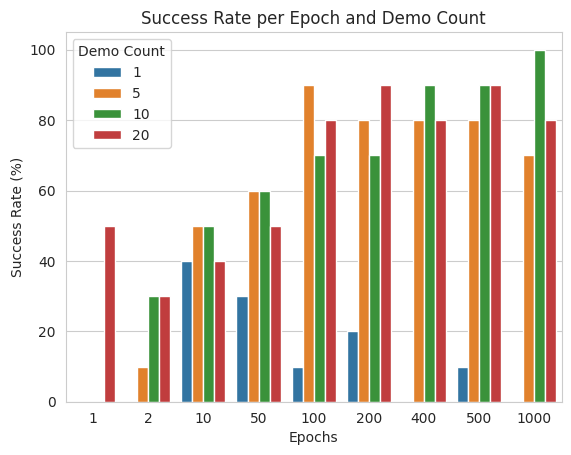

In [3]:
df = pd.read_csv("report-data/reach-no-obs/rno-place_random.csv")
df["success"] = df["done_count"].apply(lambda dc: 100 *  dc / 10)
## remove epochs greated than 10,000 dont really need them

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.barplot(data = obs_df, x="epochs", y="success", hue="demo_count", errorbar="sd", palette="tab10")
plt.ylabel("Success Rate (%)")
plt.xlabel("Epochs")
plt.title("Success Rate per Epoch and Demo Count")
plt.legend(title="Demo Count")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-success.png", format="png", dpi=DPI)
plt.show()



## Different Cameras

In [5]:
df = pd.read_csv("report-data/reach-no-obs/place_random-cam.csv")

## remove epochs greated than 10,000 dont really need them
# df = df[df["epochs"] <= 500]
obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]




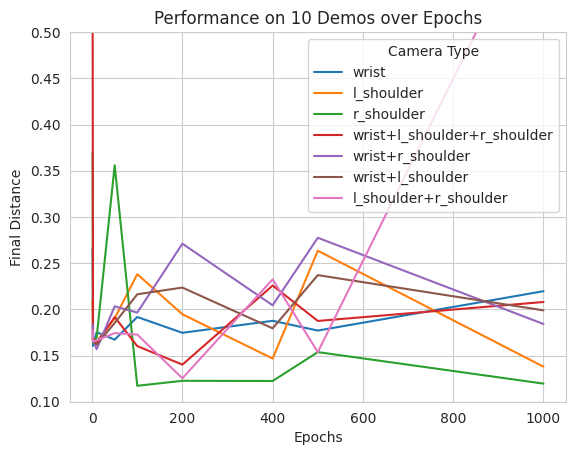

In [6]:
sns.lineplot(data = obs_df, x="epochs", y="final_distance", hue="cam_type", errorbar="sd", palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.ylim(0.1, 0.50)
plt.title("Performance on 10 Demos over Epochs")
plt.legend(title="Camera Type")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-cams.png", format="png", dpi=DPI)
plt.show()

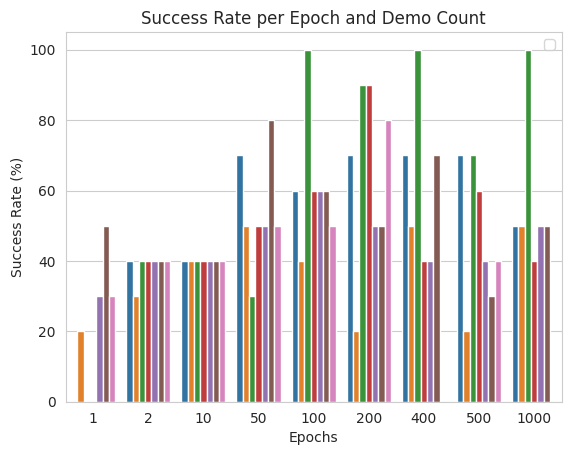

In [7]:
df["success"] = df["done_count"].apply(lambda dc: 100 *  dc / 10)
## remove epochs greated than 10,000 dont really need them

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]

sns.barplot(data = obs_df, x="epochs", y="success", hue="cam_type", errorbar="sd", palette="tab10")
plt.ylabel("Success Rate (%)")
plt.xlabel("Epochs")
plt.title("Success Rate per Epoch and Demo Count")
plt.legend("")
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_random-cam_success.png", format="png", dpi=DPI)
plt.show()


# Reach Obs

## MultiCam Reach


In [58]:
df = pd.read_csv("report-data/reach-obs/multicam/ro-randoms-cam.csv")
df["success_pct"] = df["done_count"].apply(lambda c: 10 * c)

obs_df = df[df["dataset_type"] == "obs"]
demo_df = df[df["dataset_type"] == "demo"]



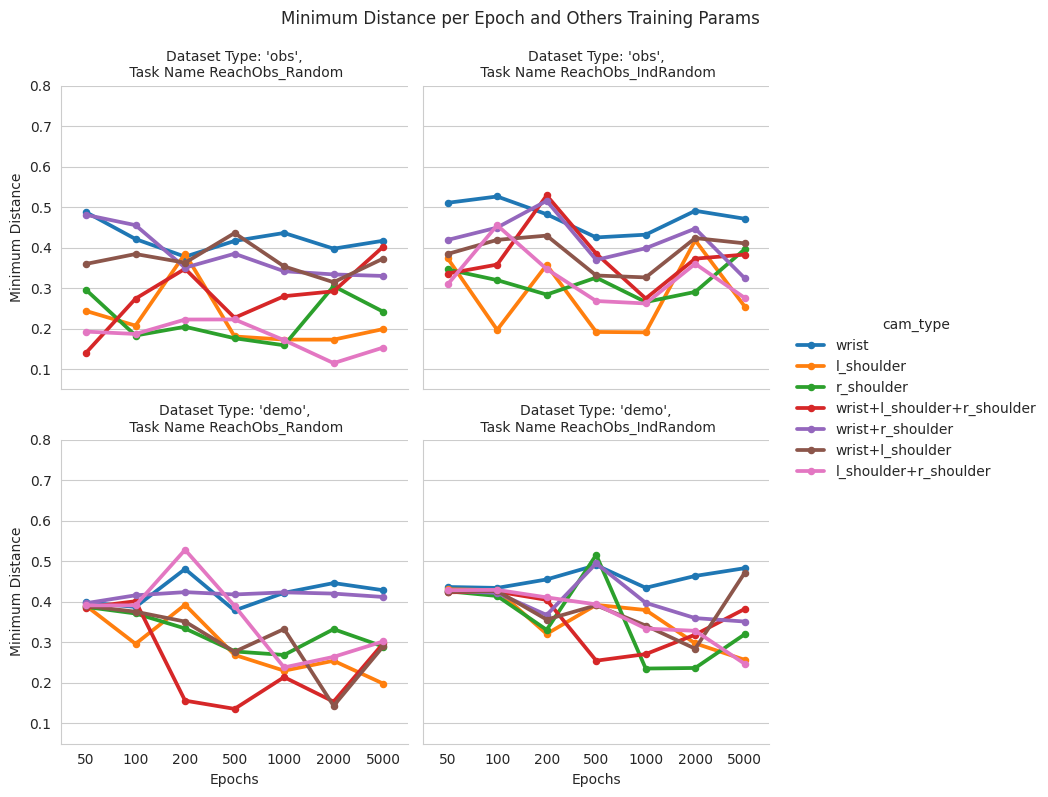

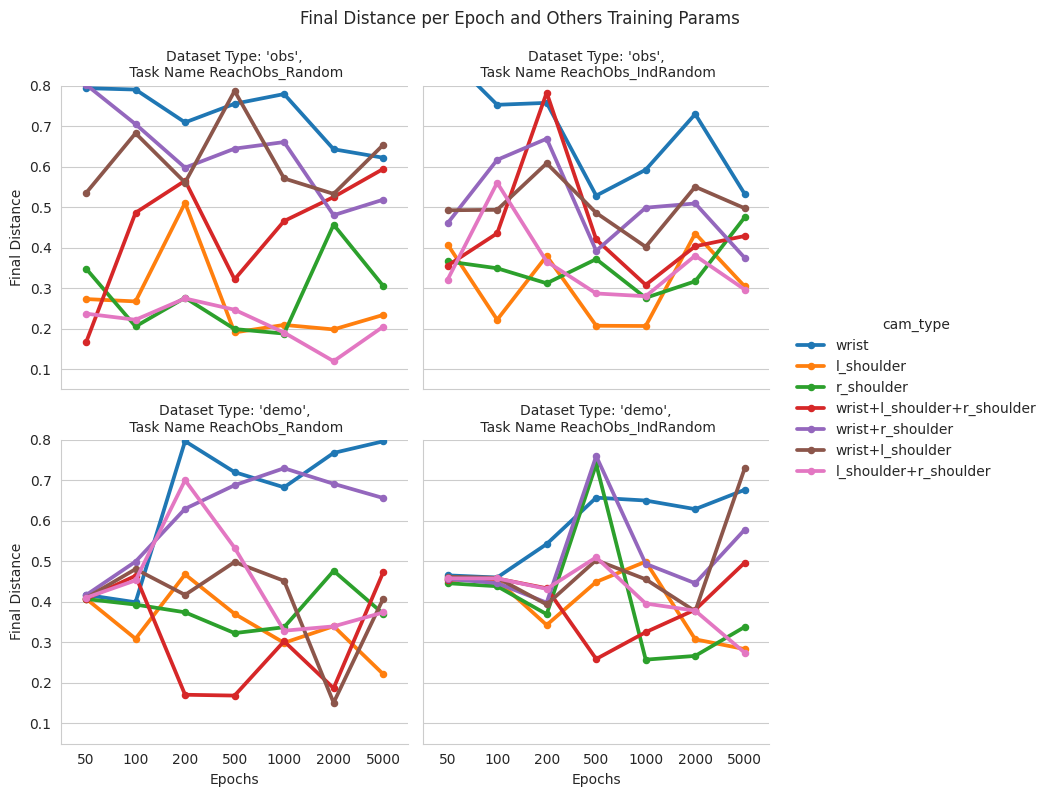

In [59]:
# Plot
mint = "min_distance", "Minimum"
finalt = "final_distance", "Final"

for ycol, Name in [mint, finalt]:
  g = sns.catplot(
      data=df,
      x='epochs',
      y=ycol,
      hue='cam_type',
      col='task_name',
      row='dataset_type',
      kind="point",
      errorbar=None,
      markers=["."] * 10,
      palette="tab10",
      height=4,
      aspect=1,
  )

  g.set_titles("Dataset Type: '{row_name}',\n Task Name {col_name}")
  g.set_axis_labels("Epochs", f"{Name} Distance")
  g.set(ylim=(0.05, 0.8))
  g.tight_layout()
  g.figure.suptitle(f"{Name} Distance per Epoch and Others Training Params", y=0.99)
  savefig(f"cam-comb/reach-obs/Z-ro_random-{Name}-dist.png", g = g)
  plt.show()

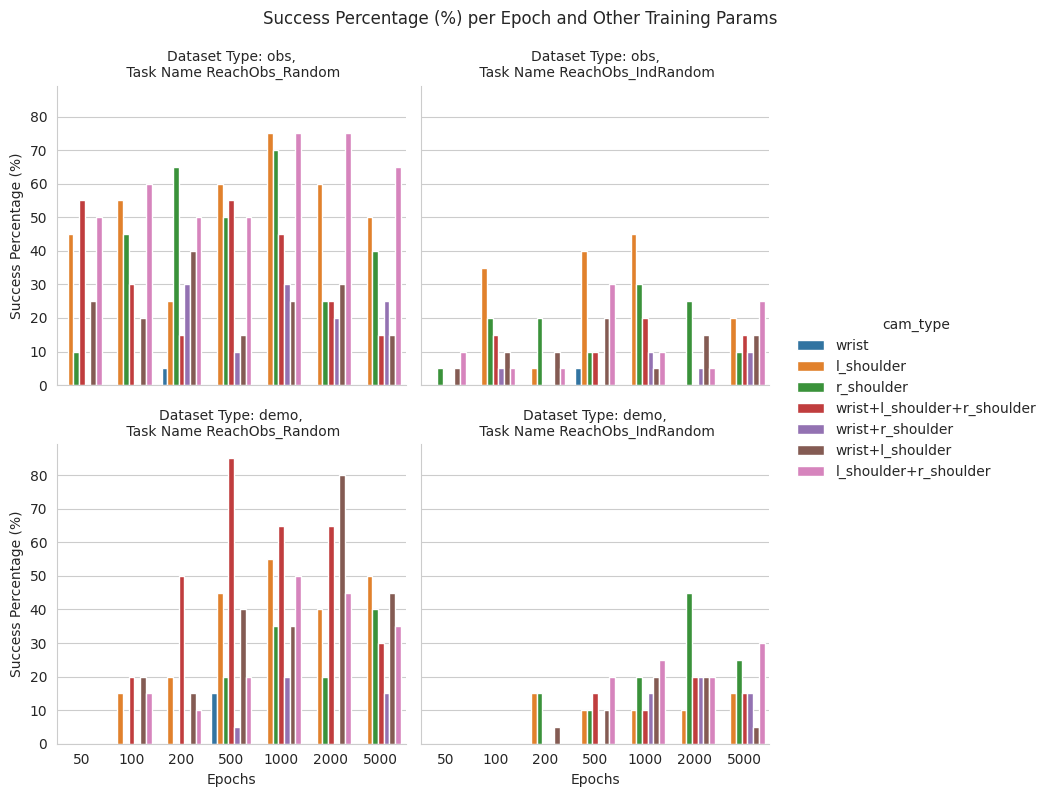

In [17]:
# Plot
g = sns.catplot(
    data=df,
    x='epochs',
    y='success_pct',
    hue='cam_type',
    col='task_name',
    row='dataset_type',
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

g.set_titles("Dataset Type: {row_name},\n Task Name {col_name}")
g.set_axis_labels("Epochs", "Success Percentage (%)")
g.figure.suptitle("Success Percentage (%) per Epoch and Other Training Params", y=0.99)#
savefig(f"cam-comb/reach-obs/Z-ro_random-success.png", g = g)
plt.show()


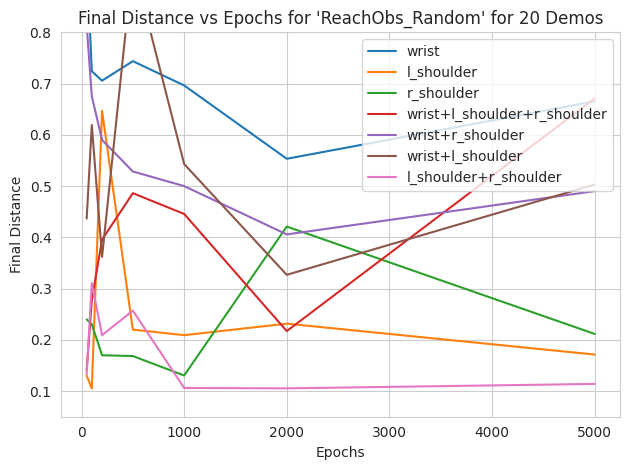

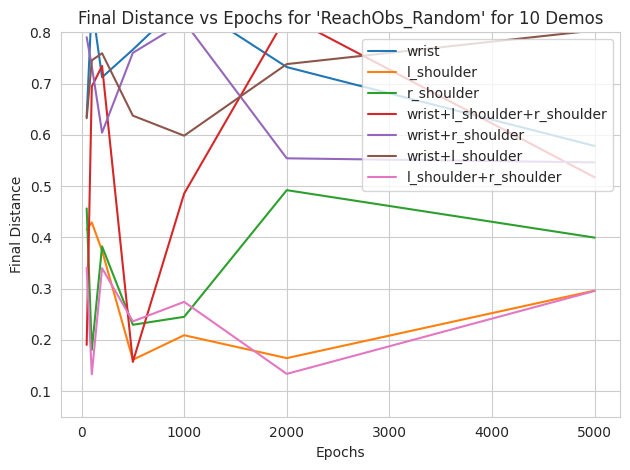

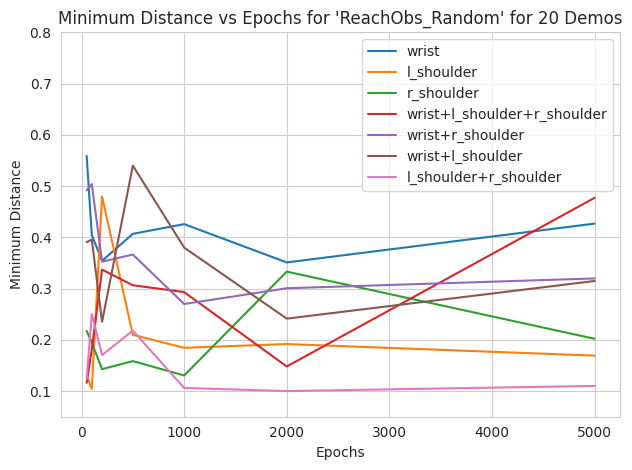

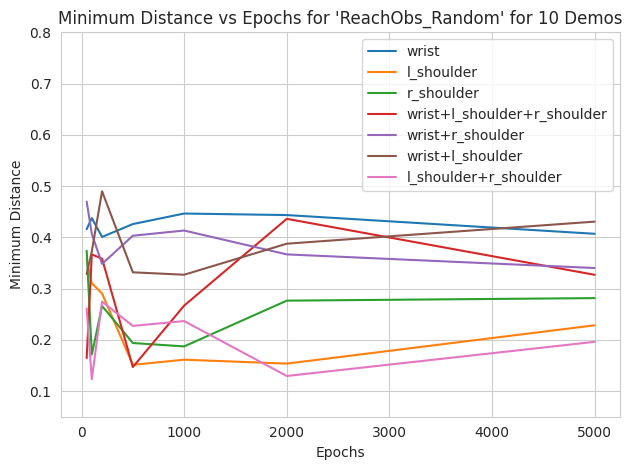

In [60]:
obs_rand = obs_df[obs_df["task_name"] == "ReachObs_Random"]
obs_ind = obs_df[obs_df["task_name"] == "ReachObs_IndRandom"]
# plt.figure(figsize=fs)
obs_rand20 = obs_rand[obs_rand["demo_count"] == 20]
obs_rand10 = obs_rand[obs_rand["demo_count"] == 10]

obs_ind20 = obs_ind[obs_ind["demo_count"] == 20]
obs_ind10 = obs_ind[obs_ind["demo_count"] == 10]

sns.lineplot(data = obs_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-obs-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-obs-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-obs-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = obs_rand10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-obs-mindist-10demos.png", format="png", dpi=DPI)
plt.show()






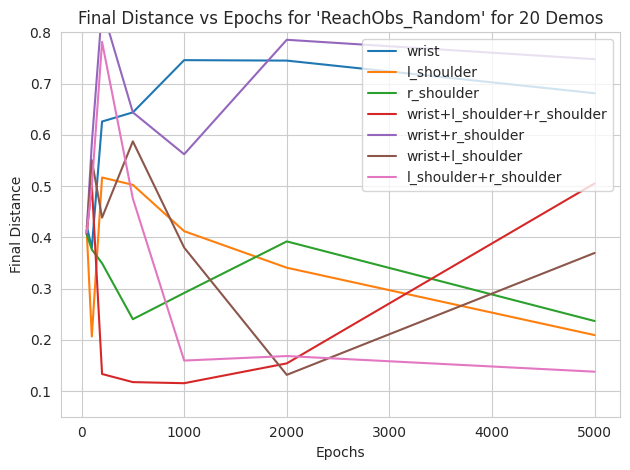

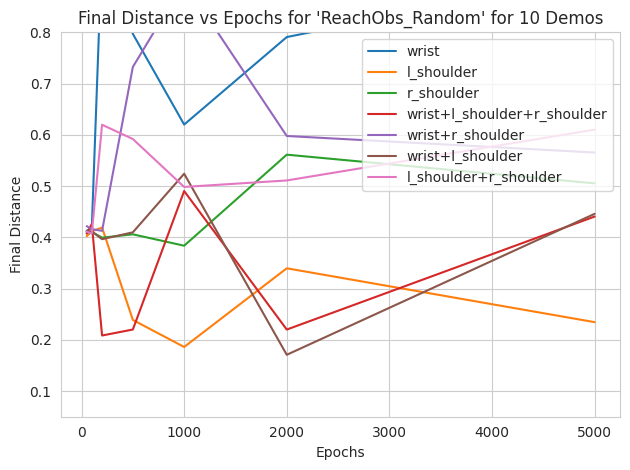

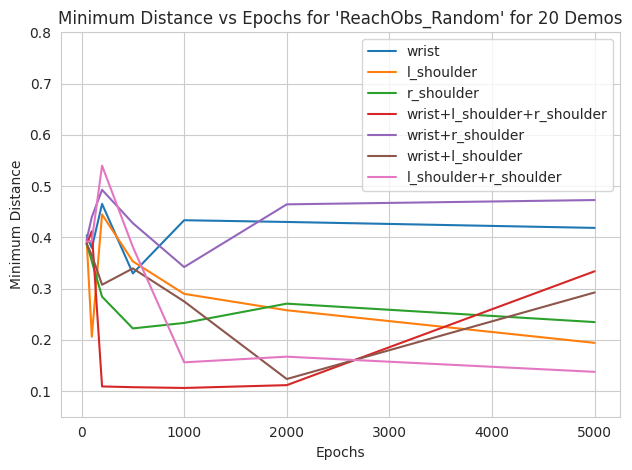

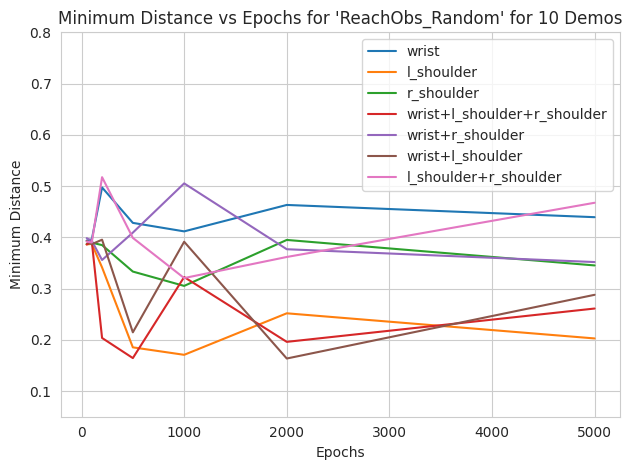

In [ ]:
demo_rand = demo_df[demo_df["task_name"] == "ReachObs_Random"]
demo_ind = demo_df[demo_df["task_name"] == "ReachObs_IndRandom"]

demo_rand20 = demo_rand[demo_rand["demo_count"] == 20]
demo_rand10 = demo_rand[demo_rand["demo_count"] == 10]

demo_ind20 = demo_ind[demo_ind["demo_count"] == 20]
demo_ind10 = demo_ind[demo_ind["demo_count"] == 10]

sns.lineplot(data = demo_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-demo-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = demo_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-demo-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = demo_rand20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-demo-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data = demo_rand10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-mindist-10demos.png", format="png", dpi=DPI)
plt.show()

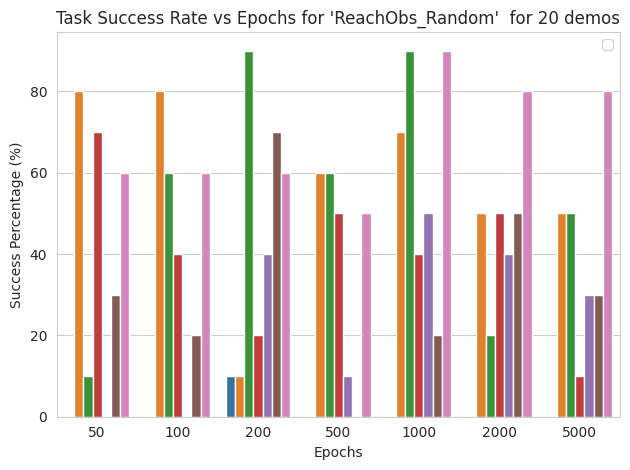

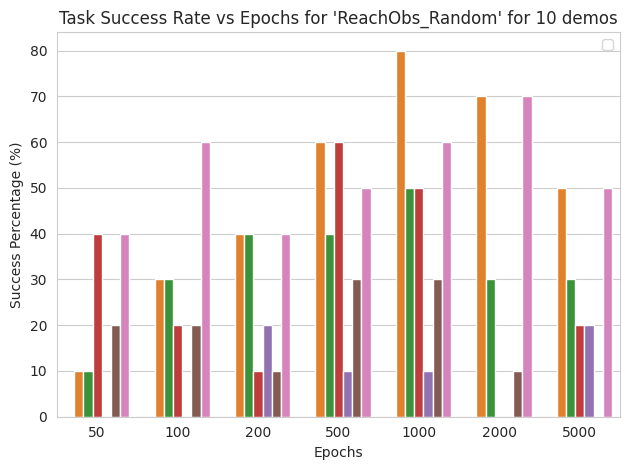

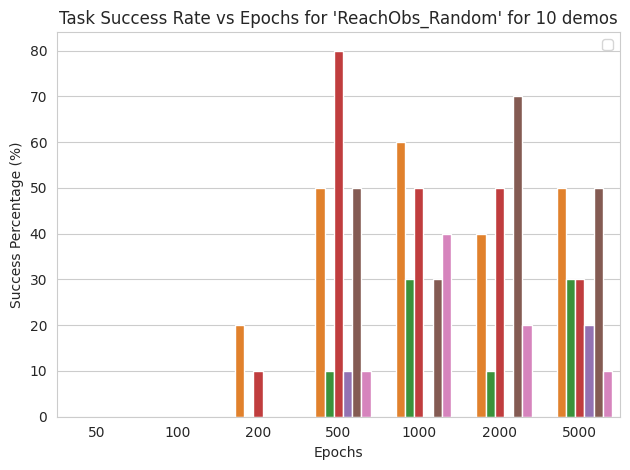

In [ ]:
# g = sns.catplot(
#   data = obs_df, 
#   y = "success_pct", 
#   x = "epochs",
#   hue = "cam_type",
#   row ="task_name",
#   kind="bar",
#   errorbar=None,
#   height=4,
#   aspect=1.3
# )
# g.set_titles("Task Name : {row_name}")
# g.set_axis_labels("Epochs", "Success Rate (%)")
# g.tight_layout()
# g.figure.suptitle("Task Success per Task and Epochs")
# plt.subplots_adjust(top=0.9)
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-success.png", format="png", dpi=DPI)
# plt.show()
sns.barplot(data = obs_rand20, x="epochs", y="success_pct", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Percentage (%)")
plt.title("Task Success Rate vs Epochs for 'ReachObs_Random'  for 20 demos")
# plt.ylim(0.05, 0.8)
# plt.legend(loc="lower right")
plt.legend("")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/Z-ro_random-obs-success-20demos.png", format="png", dpi=DPI)
plt.show()

sns.barplot(data = obs_rand10, x="epochs", y="success_pct", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Percentage (%)")
plt.title("Task Success Rate vs Epochs for 'ReachObs_Random' for 10 demos")
# plt.ylim(0.05, 0.8)
# plt.legend(loc="lower right")
plt.legend("")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-obs-success-10demos.png", format="png", dpi=DPI)
plt.show()


sns.barplot(data = demo_rand10, x="epochs", y="success_pct", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Percentage (%)")
plt.title("Task Success Rate vs Epochs for 'ReachObs_Random' for 10 demos")
# plt.ylim(0.05, 0.8)
# plt.legend(loc="lower right")
plt.legend("")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-success-10demos.png", format="png", dpi=DPI)
plt.show()




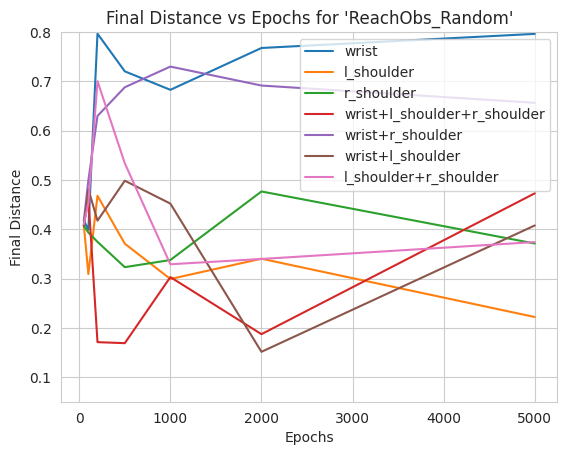

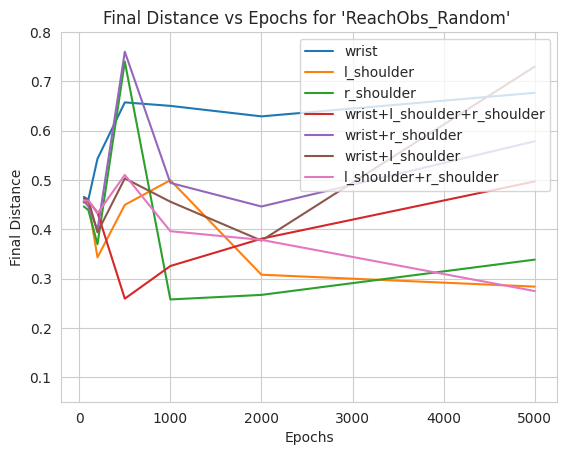

In [ ]:
obs_rand = demo_df[demo_df["task_name"] == "ReachObs_Random"]
obs_ind = demo_df[demo_df["task_name"] == "ReachObs_IndRandom"]
# plt.figure(figsize=fs)
sns.lineplot(data = obs_rand, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random'")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.show()

# plt.figure(figsize=fs)
sns.lineplot(data = obs_ind, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' ")
plt.legend(loc="upper right")
plt.ylim(0.05, 0.8)
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-no-obs/rno_static.png", format="png", dpi=DPI)
plt.show()

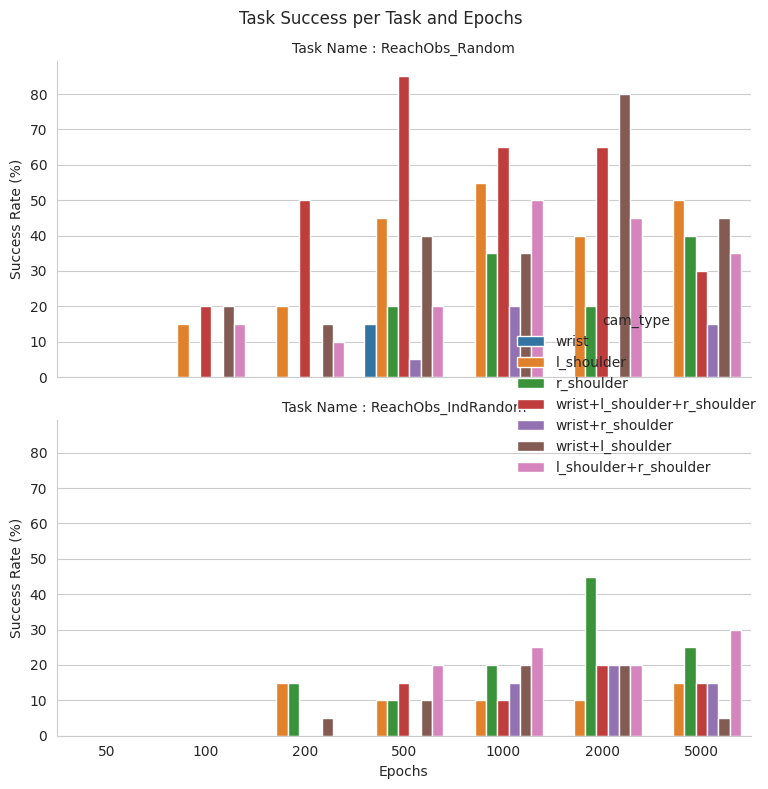

In [ ]:
g = sns.catplot(
  data = demo_df, 
  y = "success_pct", 
  x = "epochs",
  hue = "cam_type",
  row ="task_name",
  kind="bar",
  errorbar=None,
  height=4,
  aspect=1.3
)
g.set_titles("Task Name : {row_name}")
g.set_axis_labels("Epochs", "Success Rate (%)")
g.tight_layout()
g.figure.suptitle("Task Success per Task and Epochs")
plt.subplots_adjust(top=0.9)
plt.tight_layout()
plt.show()



"obs" dataset performs better at thsi task and is generally more successful at crossing the obstacle
- this i hypothesise is because here it was trained with mbsize = 32, which is around half the demo episode length (around 82 here) I think what this achieves is that the robot (by chance) learns the two parts of the movement in tandem, so for every epoch before the loss is updated the robot will see 
(mention in presentation definitely one of the nice things i might have found out)

do a run with exactly half of max  eplen to check if this improves it?

while "demo" is updated demowise so mbsize = 1 (demo), this means that the loss is updated after each demo, which makes the robot learn a middleground optimal way to just bonk on the obstacle most of the time, and clearly fails to cross the obstacle as often as obs does

## Multicam Reach - Demo Dataset with mbsize: 10
all data is using the "demo" dataset, will also run a varying minibatch search later at night


In [ ]:
df = pd.read_csv("report-data/reach-obs/multicam/demo-rerun-mbsize:10--ro-randoms-cam.csv")
df["success_pct"] = df["done_count"].apply(lambda c: 10 * c)

df_rand = df[df["task_name"] == "ReachObs_Random"]
df_ind = df[df["task_name"] == "ReachObs_IndRandom"]

df_rand10 = df_rand[df_rand["demo_count"] == 10]
df_rand20 = df_rand[df_rand["demo_count"] == 20]

df_ind10 = df_ind[df_ind["demo_count"] == 10]
df_ind20 = df_ind[df_ind["demo_count"] == 20]

### ReachObs_Random

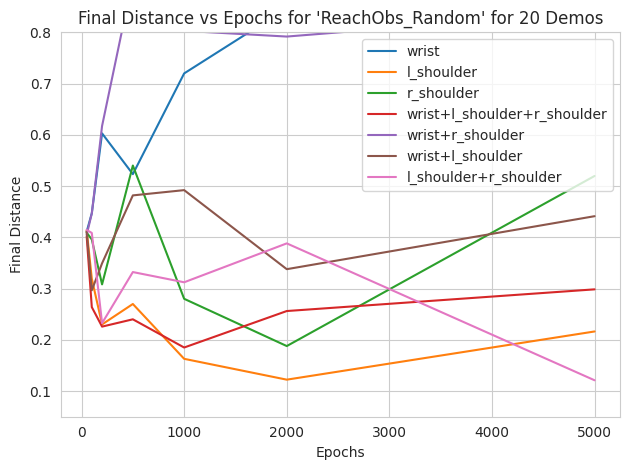

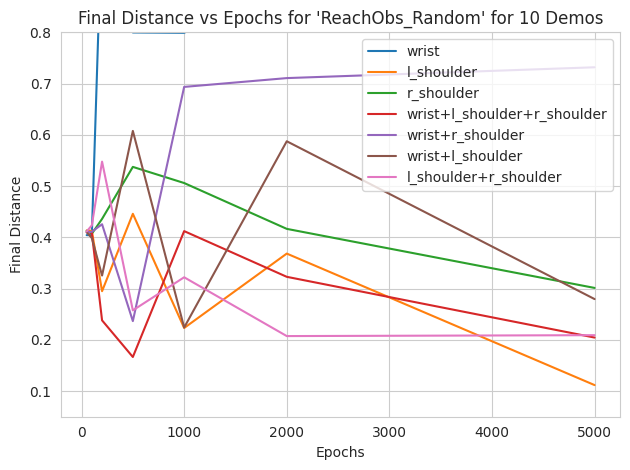

KeyboardInterrupt: 

In [ ]:
sns.lineplot(data=df_rand20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_rand10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_rand20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_rand10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_Random' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_random-demo-mindist-10demos.png", format="png", dpi=DPI)
plt.show()

### ReachObs_IndRandom


In [ ]:
sns.lineplot(data=df_ind20, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_IndRandom' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-dist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_ind10, x="epochs", y="final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Final Distance")
plt.title("Final Distance vs Epochs for 'ReachObs_IndRandom' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-dist-10demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_ind20, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_IndRandom' for 20 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-mindist-20demos.png", format="png", dpi=DPI)
plt.show()

sns.lineplot(data=df_ind10, x="epochs", y="min_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Minimum Distance")
plt.title("Minimum Distance vs Epochs for 'ReachObs_IndRandom' for 10 Demos")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/ro_indrandom-demo-mindist-10demos.png", format="png", dpi=DPI)
plt.show()

## Reach - batch size check for "obs"


In [ ]:
df = pd.read_csv("report-data/reach-obs/multicam/obs-rerun-mbsize:40-64-100--ro-randoms-cam.csv")
df["success_pct"] = df["done_count"].apply(lambda c: 10 * c)
obs_rand = df[df["task_name"] == "ReachObs_Random"]
obs_ind = df[df["task_name"] == "ReachObs_IndRandom"]
# plt.figure(figsize=fs)
obs_rand20 = obs_rand[obs_rand["demo_count"] == 20]
obs_rand10 = obs_rand[obs_rand["demo_count"] == 10]

obs_ind20 = obs_ind[obs_ind["demo_count"] == 20]
obs_ind10 = obs_ind[obs_ind["demo_count"] == 10]


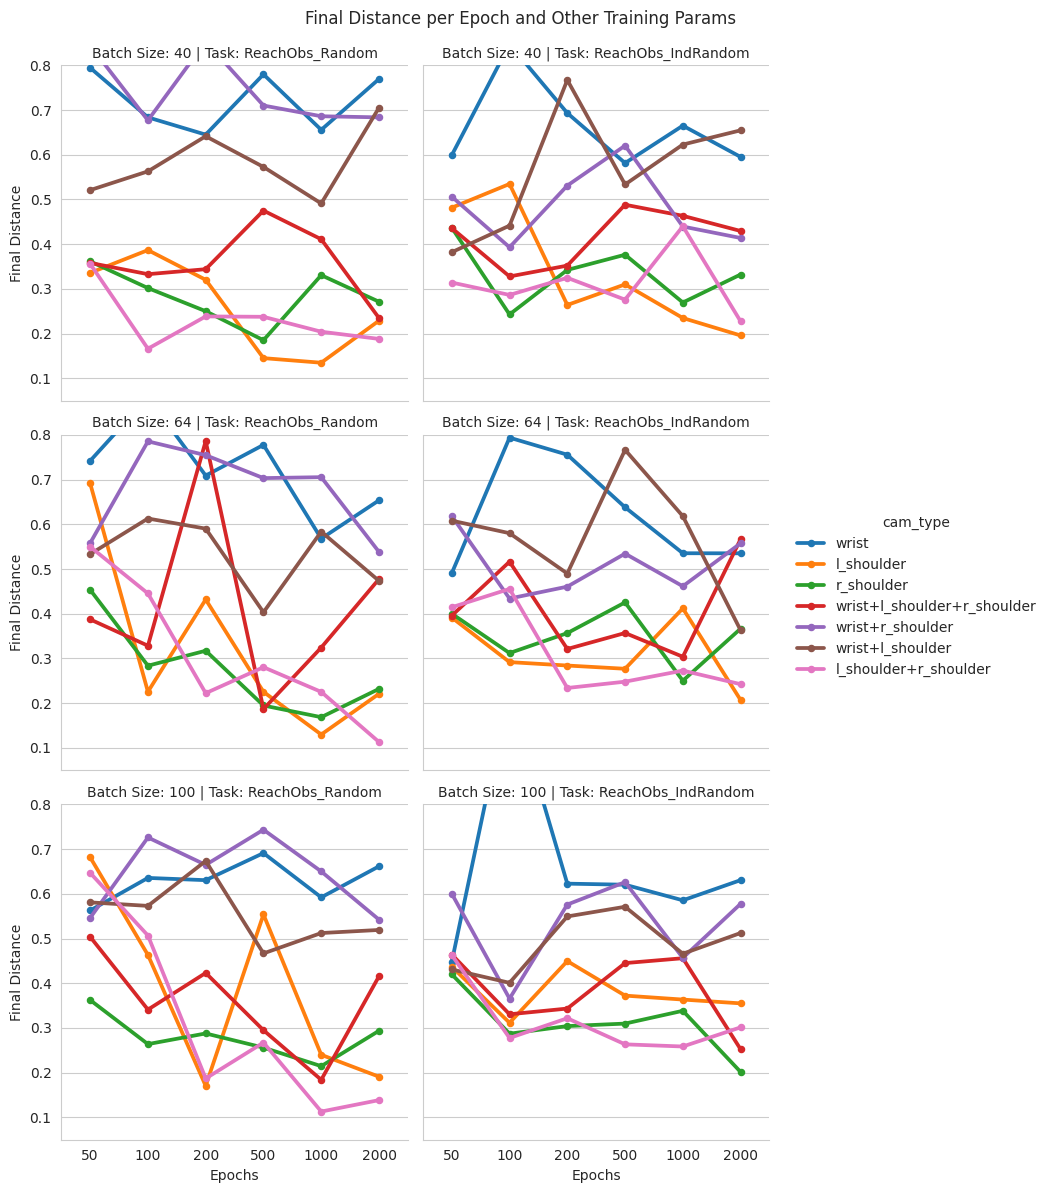

In [ ]:
# Plot
g = sns.catplot(
    data=df,
    x='epochs',
    y='final_distance',
    hue='cam_type',
    col='task_name',
    row='mbsize',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

g.set_titles("Batch Size: {row_name} | Task: {col_name}")
g.set_axis_labels("Epochs", "Final Distance")
g.set(ylim=(0.05, 0.8))
g.tight_layout()
g.figure.suptitle("Final Distance per Epoch and Other Training Params", y=0.99)
savefig("cam-comb/reach-obs/Z-ro_random-obs-dist.png", g=g)
plt.show()

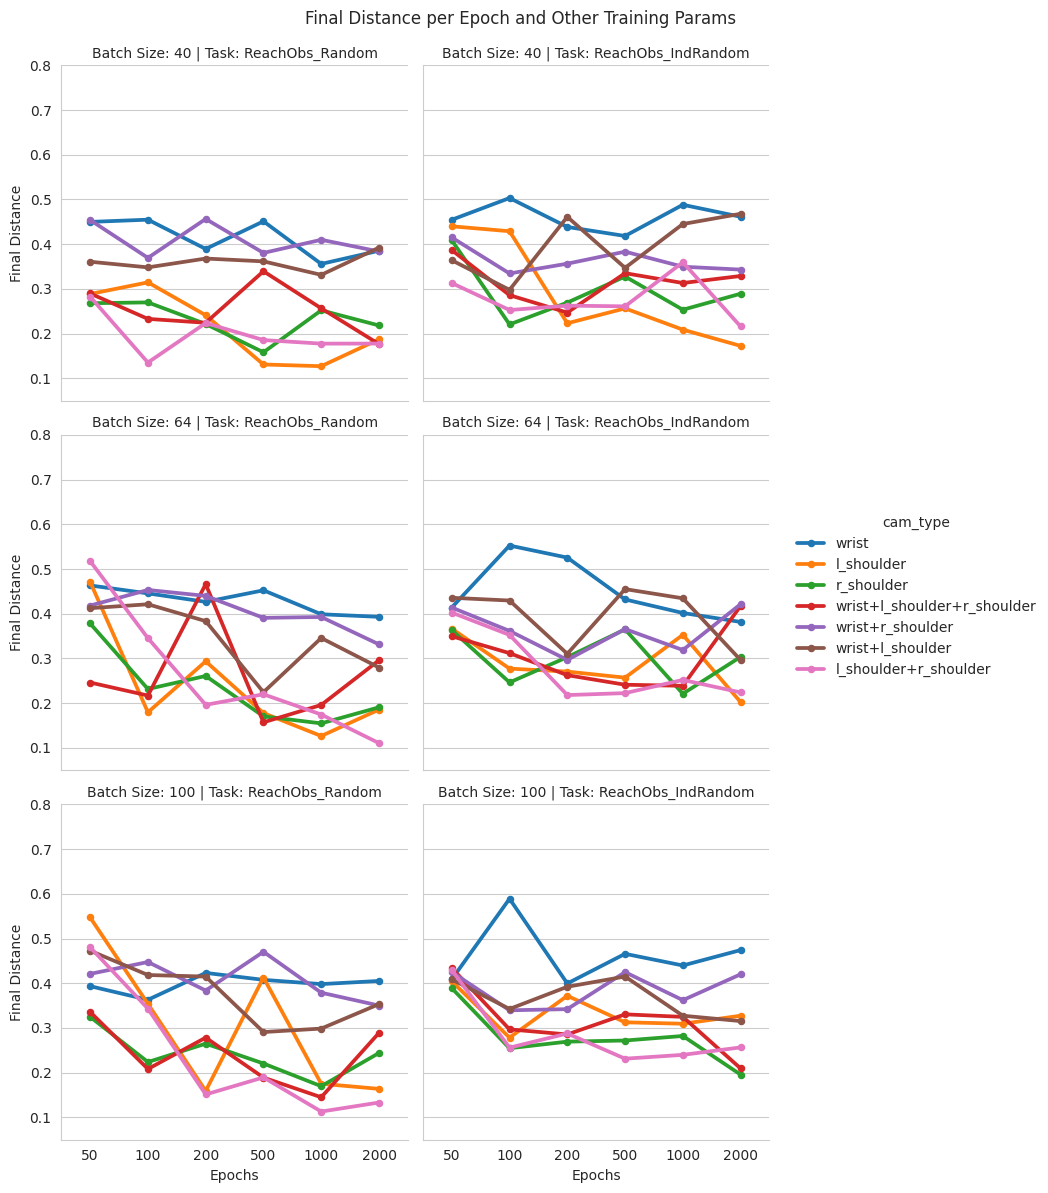

In [ ]:
# Plot
g = sns.catplot(
    data=df,
    x='epochs',
    y='min_distance',
    hue='cam_type',
    col='task_name',
    row='mbsize',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

g.set_titles("Batch Size: {row_name} | Task: {col_name}")
g.set_axis_labels("Epochs", "Final Distance")
g.set(ylim=(0.05, 0.8))
g.tight_layout()
g.figure.suptitle("Final Distance per Epoch and Other Training Params", y=0.99)
savefig("cam-comb/reach-obs/Z-ro_random-obs-mindist.png", g=g)
plt.show()

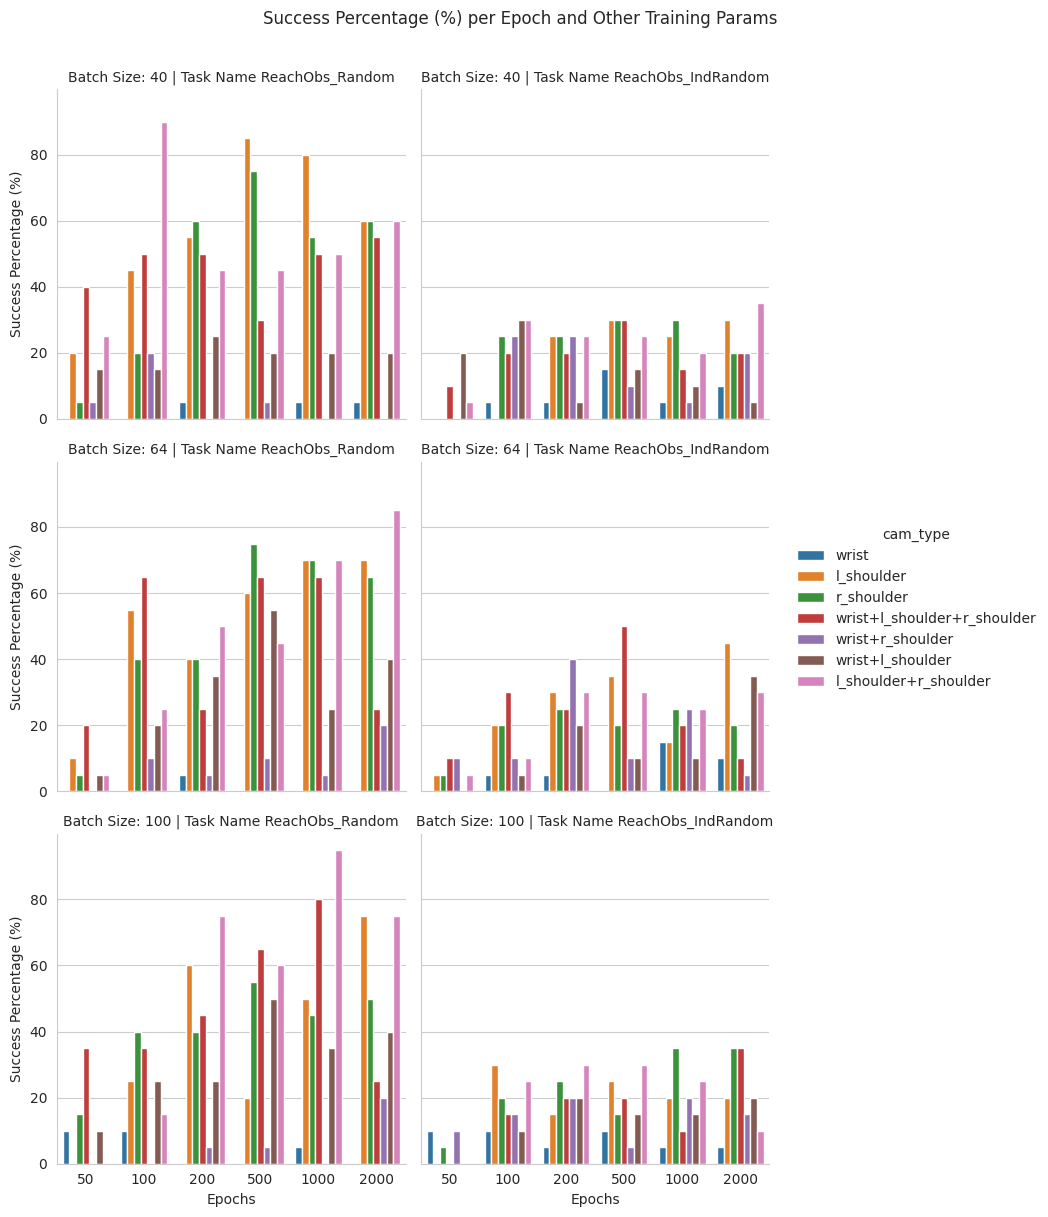

: 

In [ ]:
# Plot
g = sns.catplot(
    data=df,
    x='epochs',
    y='success_pct',
    hue='cam_type',
    col='task_name',
    row='mbsize',
    kind="bar",
    errorbar=None,
    # markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

g.set_titles("Batch Size: {row_name} | Task Name {col_name}")
g.set_axis_labels("Epochs", "Success Percentage (%)")
g.tight_layout()
g.figure.suptitle("Success Percentage (%) per Epoch and Other Training Params", y=1.01)
plt.tight_layout()
savefig("cam-comb/reach-obs/Z-ro_random-obs-trials-success.png", g=g)
plt.show()

## Cam Attn


## First new run
ran for like 125 hours, done single and multi cnn with "demo" dataset only with some other params

In [63]:
import ast
import torch
def parse_tensor_list(s: str) -> list[torch.Tensor | None]:
  s = s.strip("[]") # Remove the outer square brackets
  items = []
  i = 0
  while i < len(s):
    if s[i:i+6] == "tensor":
      # Find the full tensor(...) expression
      start = i + 7  # after "tensor("
      depth = 1
      j = start
      while j < len(s):
          if s[j] == "(":
            depth += 1
          elif s[j] == ")":
            depth -= 1
            if depth == 0: break
          j += 1
      tensor_str = s[start:j]
      values = ast.literal_eval(tensor_str)
      items.append(torch.tensor(values))
      i = j + 1  # move past the closing ")"
    elif s[i:i+4] == "None":
      items.append(None)
      i += 4
    else:
      i += 1  # Skip commas, spaces, etc.
  return items

def plot_cam_attention_heatmap(df, savepath: None | str):
  
  cam_combos = df["cam_type"].unique()
  pools = df["colour_pool"].unique()
  is_multi_cnns = df["is_multi_cnn"].unique()


  num_cams = len(cam_combos)
  num_pools = len(pools)

  for mi, is_multi_cnn in enumerate(is_multi_cnns):
    ## make a new plot for each demo count, easier to digest
    fig, axs = plt.subplots(num_cams, num_pools, figsize=(16, 10))
    for ci, cam_type in enumerate(cam_combos):
      for pi, pool in enumerate(pools):
        ax = axs[ci, pi]
        
        pool_df = df[
          (df["colour_pool"] == pool) &
          (df["cam_type"] == cam_type) &
          (df["is_multi_cnn"] == is_multi_cnn) 
        ]
        
        x_labels = cam_type.split("+")
        
        if pool_df.empty:
          continue
        tensor_above = pool_df["avg_aboves"].values[0]
        tensor_below = pool_df["avg_belows"].values[0]
        
        y_labels = ["Above", "Below"]
        stack = torch.stack([tensor_above, tensor_below], dim=0)
        sns.heatmap(ax=ax, data=stack.reshape(2, -1), cbar=True, cmap="YlGnBu", annot=True)
        
        ax.set_xticklabels(x_labels)
        ax.set_yticklabels(y_labels)
        ax.set_title(f"{cam_type} - {pool} - {10} Demo{'s' if 10 != 1 else ''} - IsMultiCnn: {is_multi_cnn}")
    fig.suptitle(f"Attention Maps for MultiCNN: {is_multi_cnn}, Above and Below the Obstacle", fontsize=16)
    plt.tight_layout()
    if savepath is not None: savefig(savepath, force_save=True)
    plt.show()


In [66]:
df = pd.read_csv("report-data/reach-obs/cam-attn/cam_attn-2pooling--ro-randoms-cam.csv")
df["belows"] = df["belows"].apply(parse_tensor_list)
df["aboves"] = df["aboves"].apply(parse_tensor_list)

df["belows_none_count"] = df["belows"].apply(lambda ts: len([t for t in ts if t is None]))
df["aboves_none_count"] = df["aboves"].apply(lambda ts: len([t for t in ts if t is None]))

df["avg_belows"] = df["belows"].apply(lambda ts: torch.stack([t for t in ts if t is not None]).mean(dim = 0))
df["avg_aboves"] = df["aboves"].apply(lambda ts: torch.stack([t for t in ts if t is not None]).mean(dim = 0))



df_max = df[df["colour_pool"] == "max"]
df_mean = df[df["colour_pool"] == "mean"]
# df = None


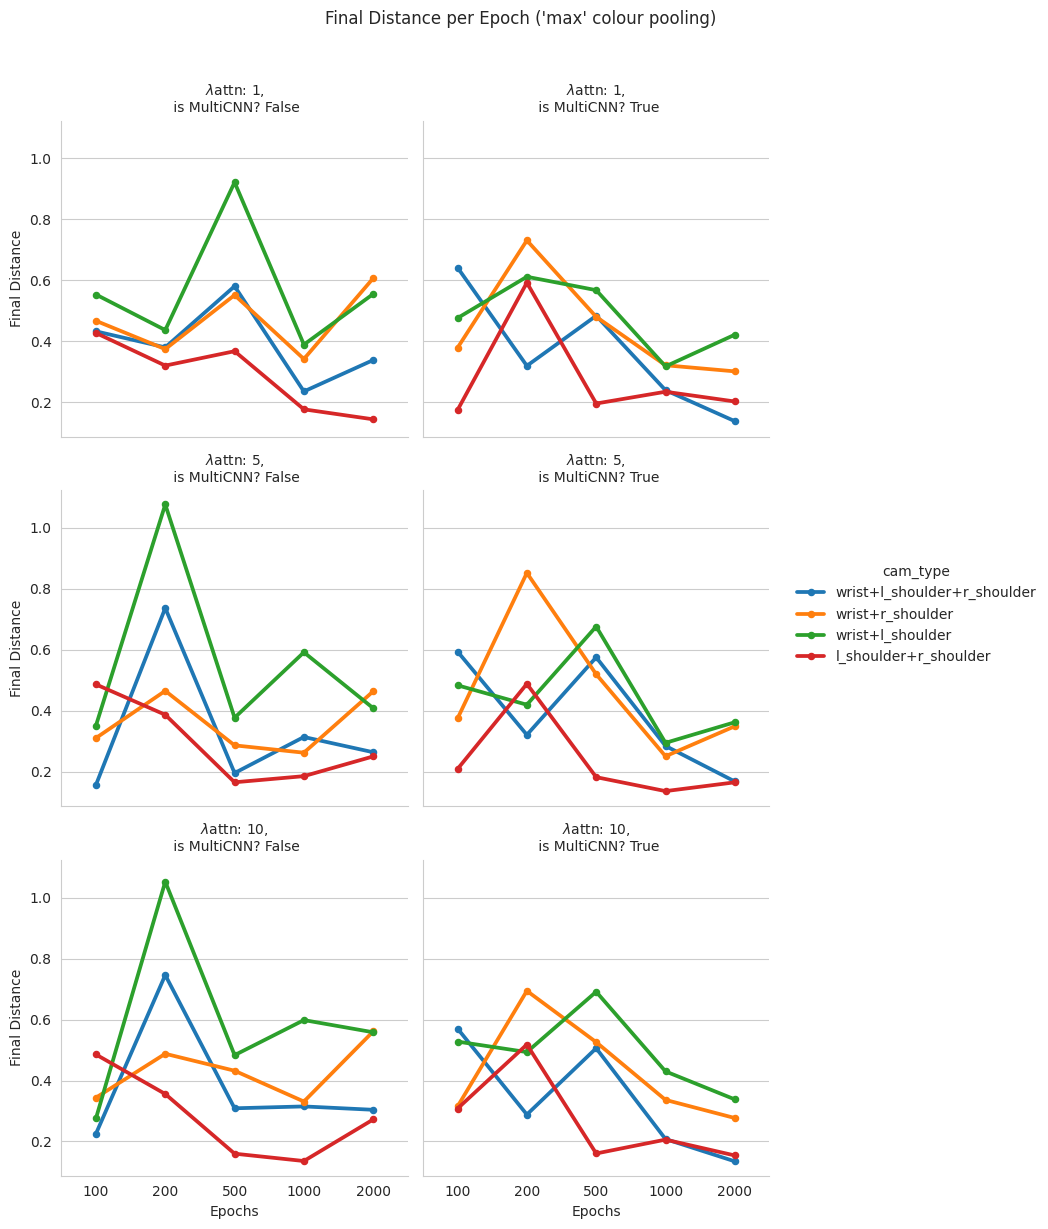

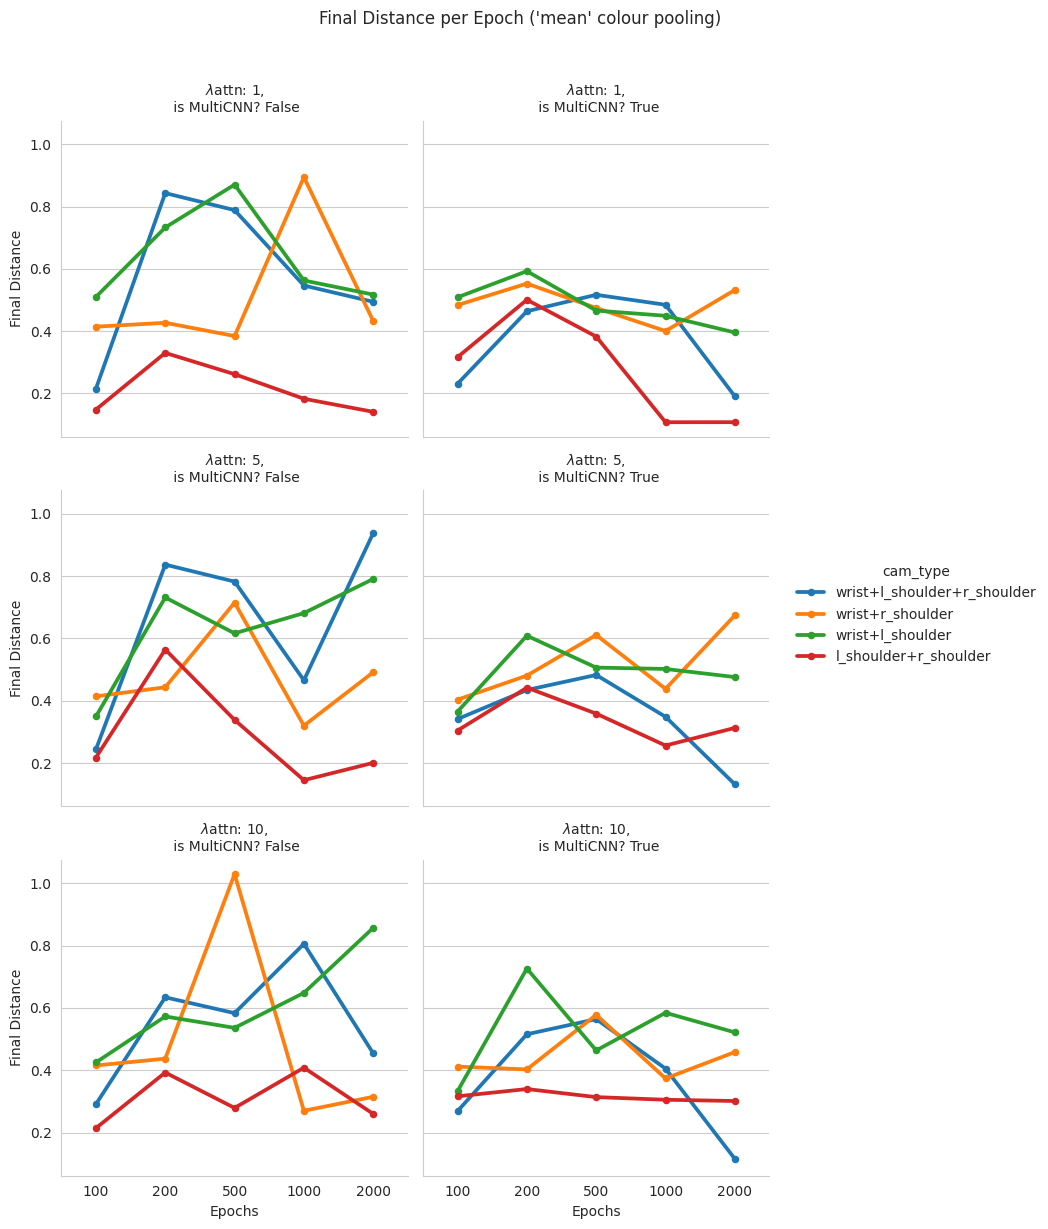

In [21]:
# Plot
g = sns.catplot(
    data=df_max,
    x='epochs',
    y='final_distance',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Final Distance")
g.figure.suptitle("Final Distance per Epoch ('max' colour pooling)", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-max-dist", g = g)
plt.show()

# Plot
g = sns.catplot(
    data=df_mean,
    x='epochs',
    y='final_distance',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Final Distance")
g.figure.suptitle("Final Distance per Epoch ('mean' colour pooling)", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-mean-dist", g = g)
plt.show()



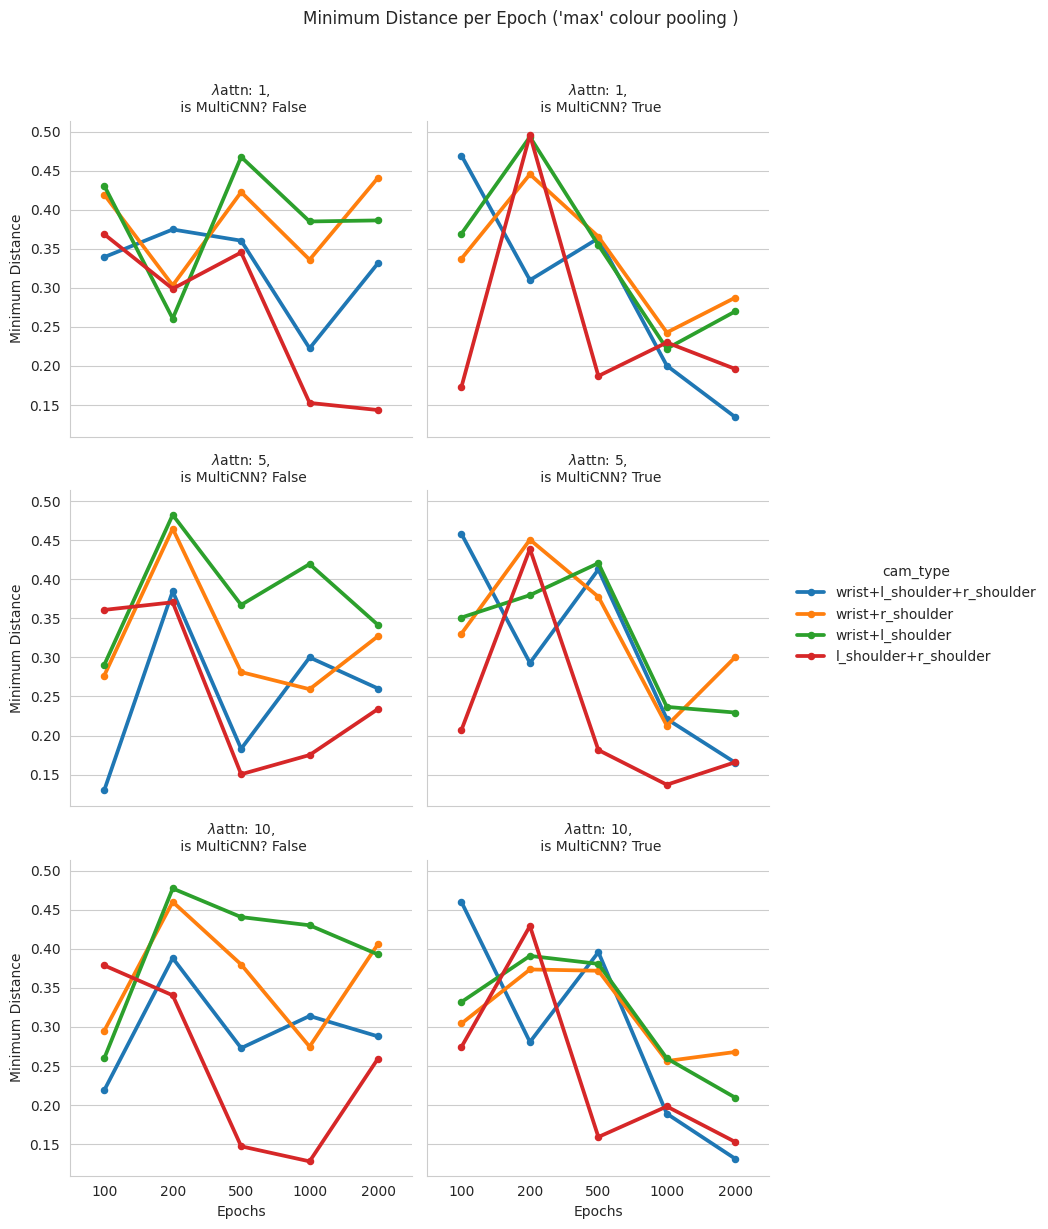

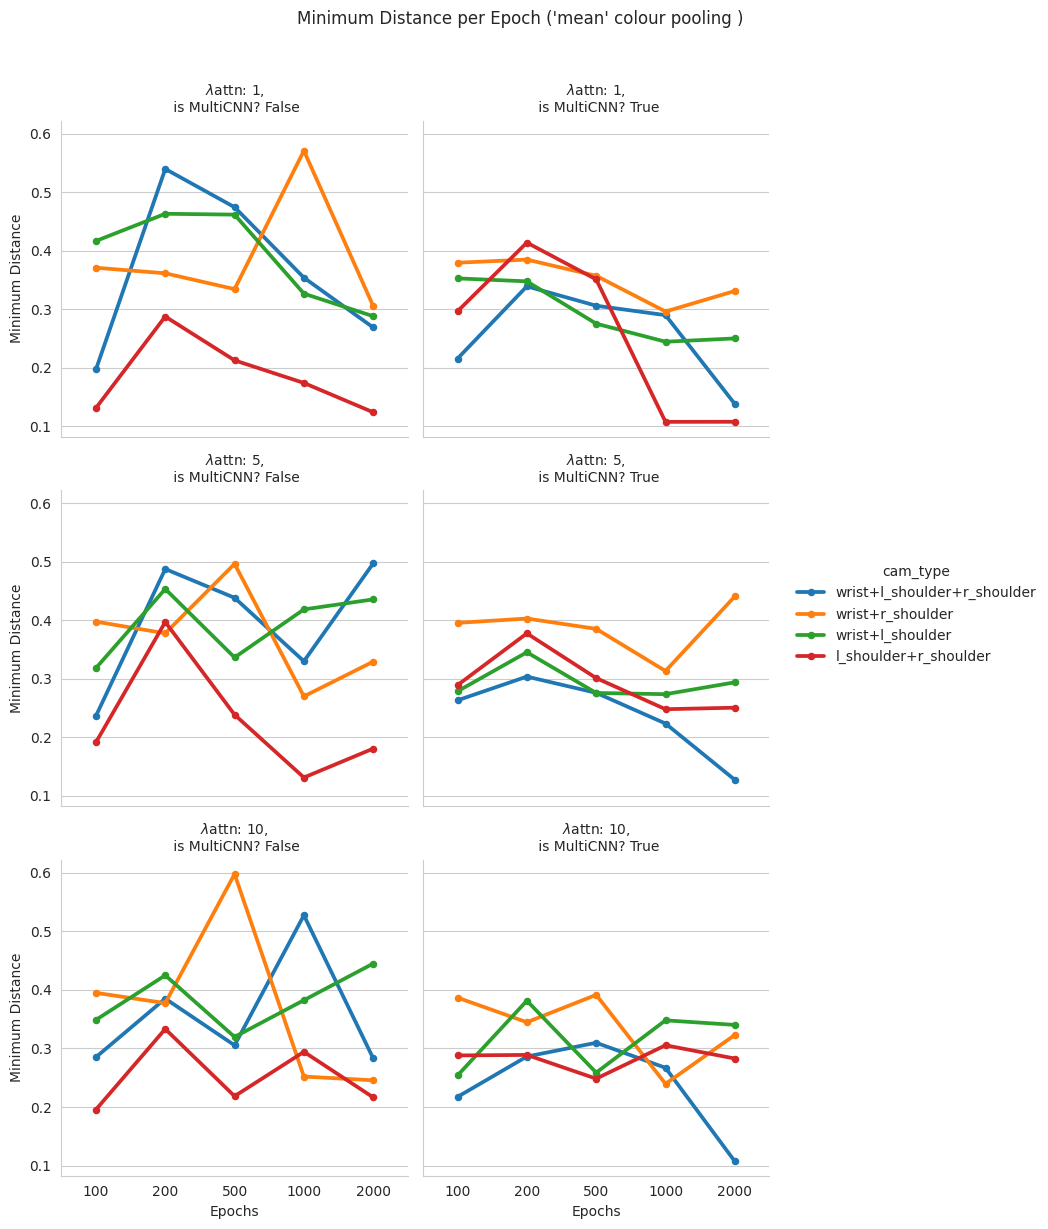

In [22]:
# Plot
g = sns.catplot(
    data=df_max,
    x='epochs',
    y='min_distance',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Minimum Distance")
g.figure.suptitle("Minimum Distance per Epoch ('max' colour pooling )", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-max-mindist", g = g)
plt.show()

# Plot
g = sns.catplot(
    data=df_mean,
    x='epochs',
    y='min_distance',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Minimum Distance")
g.figure.suptitle("Minimum Distance per Epoch ('mean' colour pooling )", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-mean-mindist", g = g)
plt.show()


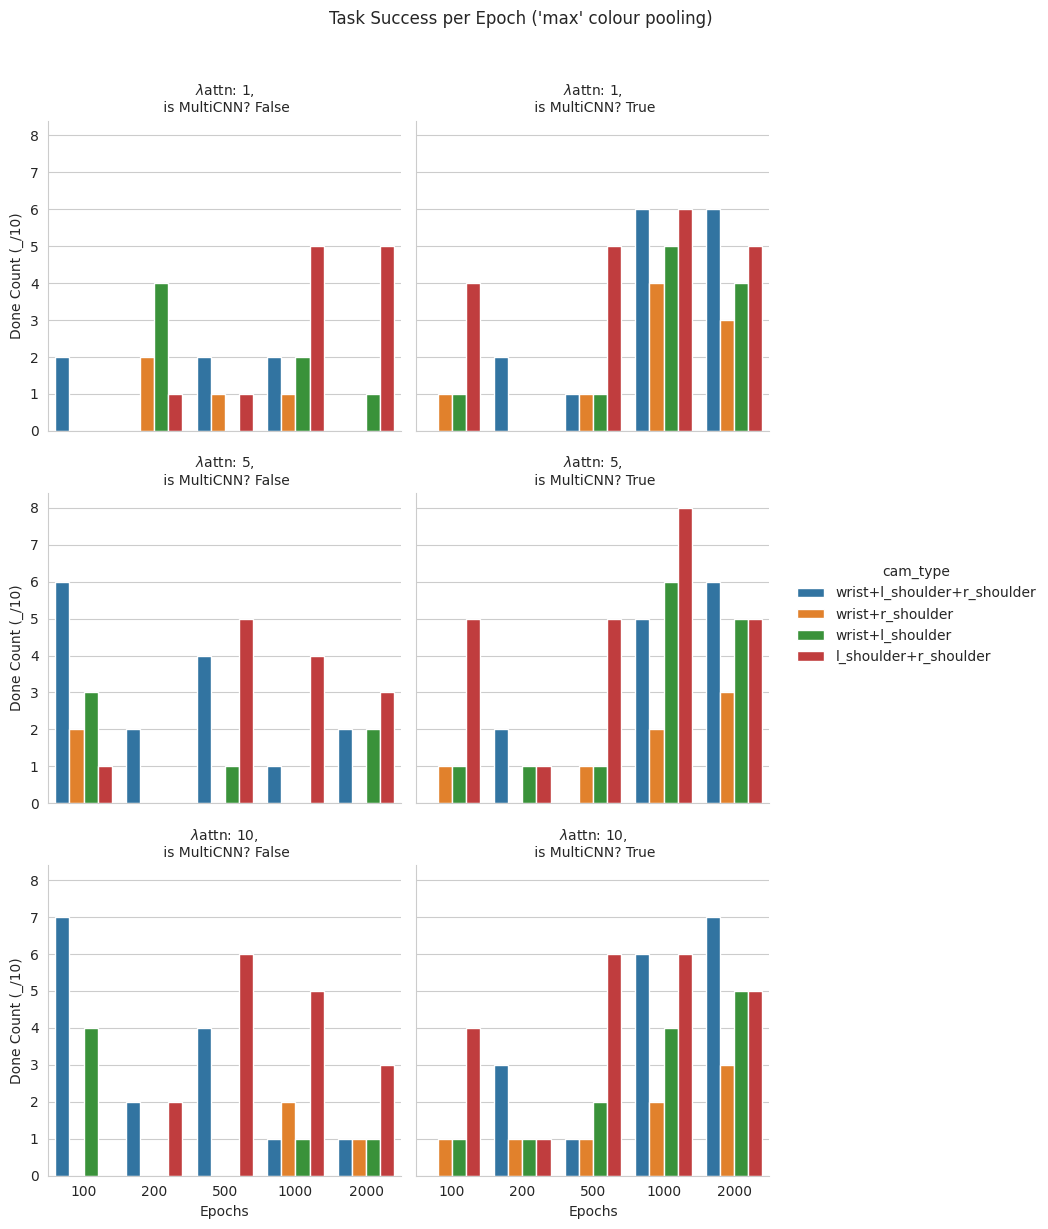

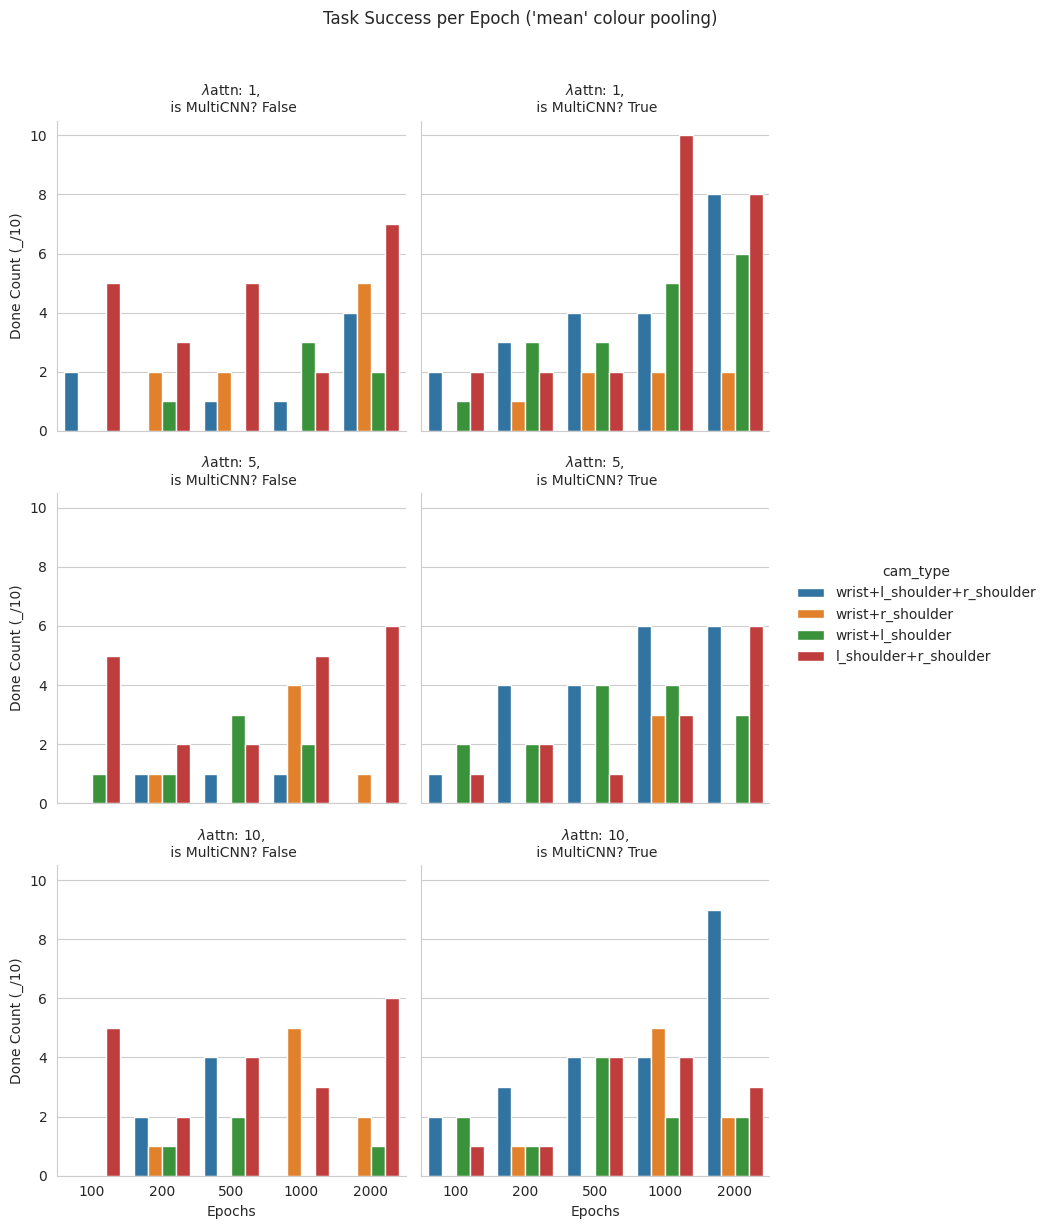

In [27]:
# Plot
g = sns.catplot(
    data=df_max,
    x='epochs',
    y='done_count',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Done Count (_/10)")
g.figure.suptitle("Task Success per Epoch ('max' colour pooling)", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-max-success", g = g)
plt.show()

# Plot mean
g = sns.catplot(
    data=df_mean,
    x='epochs',
    y='done_count',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Done Count (_/10)")
g.figure.suptitle("Task Success per Epoch ('mean' colour pooling)", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-mean-success", g = g)
plt.show()


So some plotting about the attentions above and below the obstacle

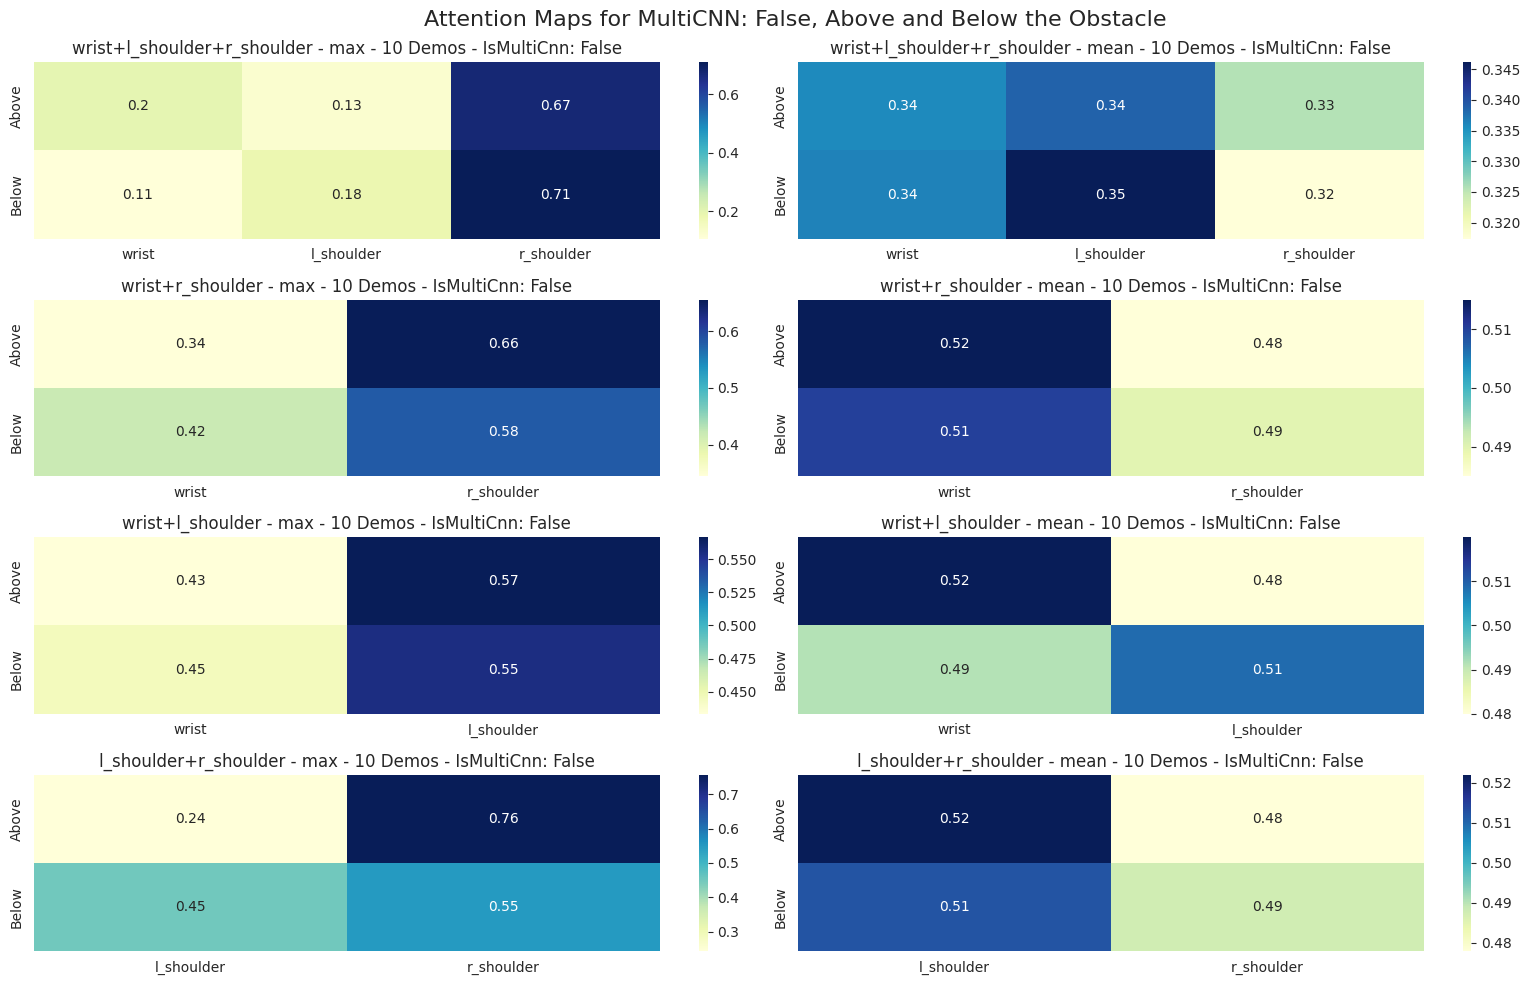

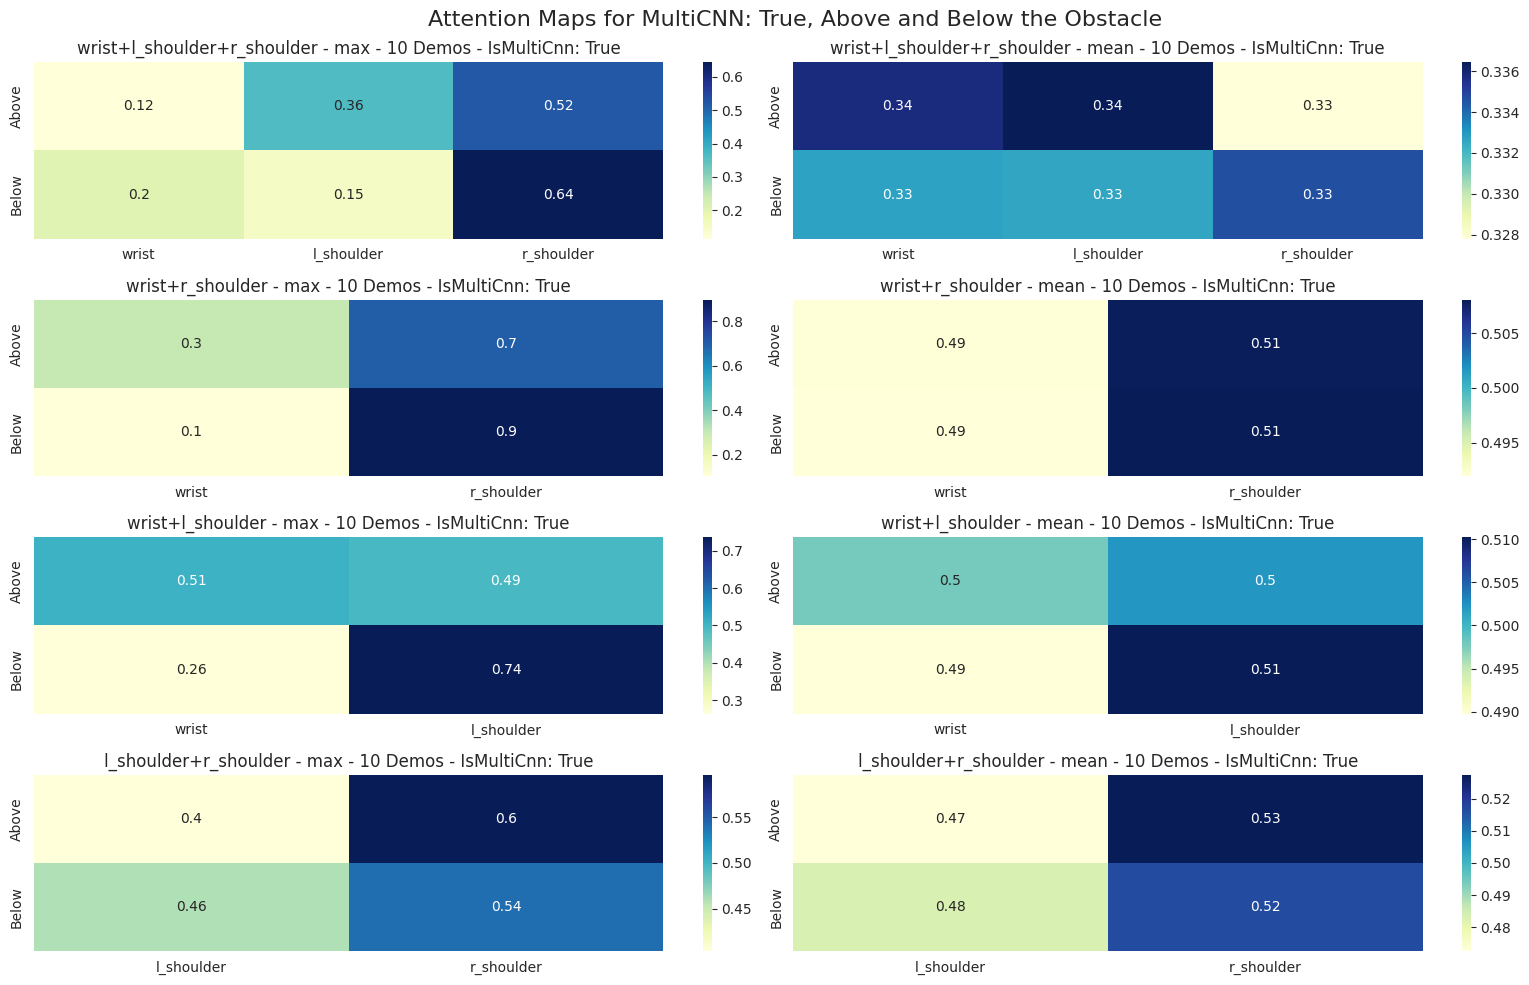

In [69]:
plot_cam_attention_heatmap(df, savepath="cam-comb/reach-obs/Z-ro_random-cam_attn-heatmaps")

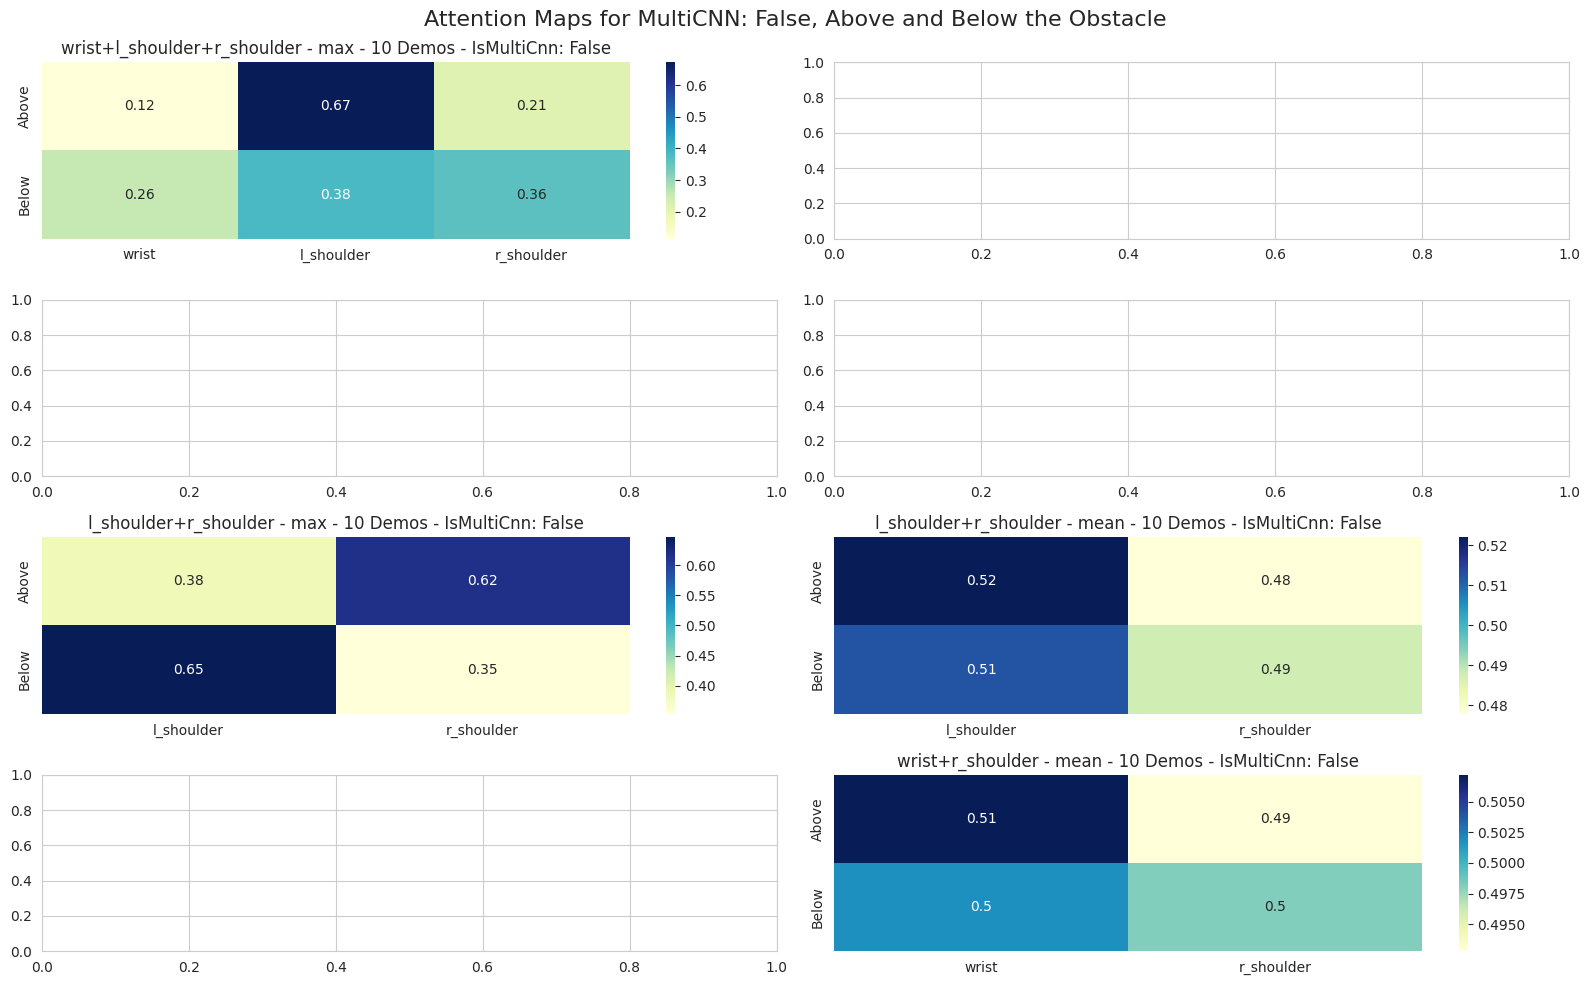

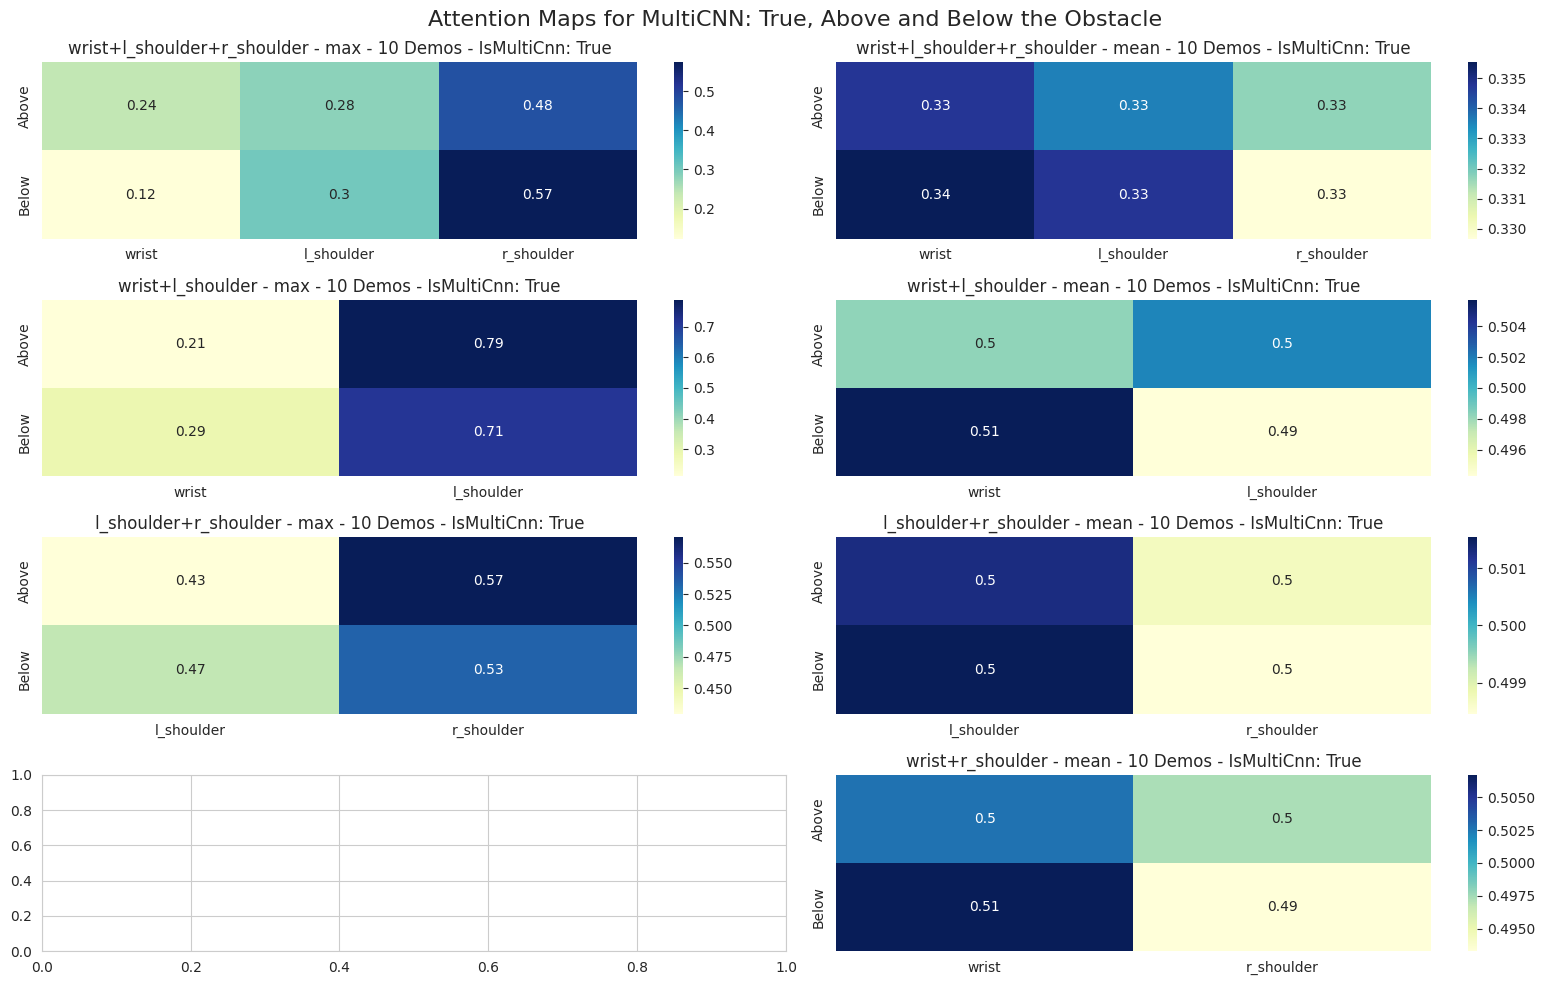

In [ ]:
plot_cam_attention_heatmap(df[df["done_count"] >= 5], savepath="cam-comb/reach-obs/Z-ro_random-cam_attn-heatmaps-5success")

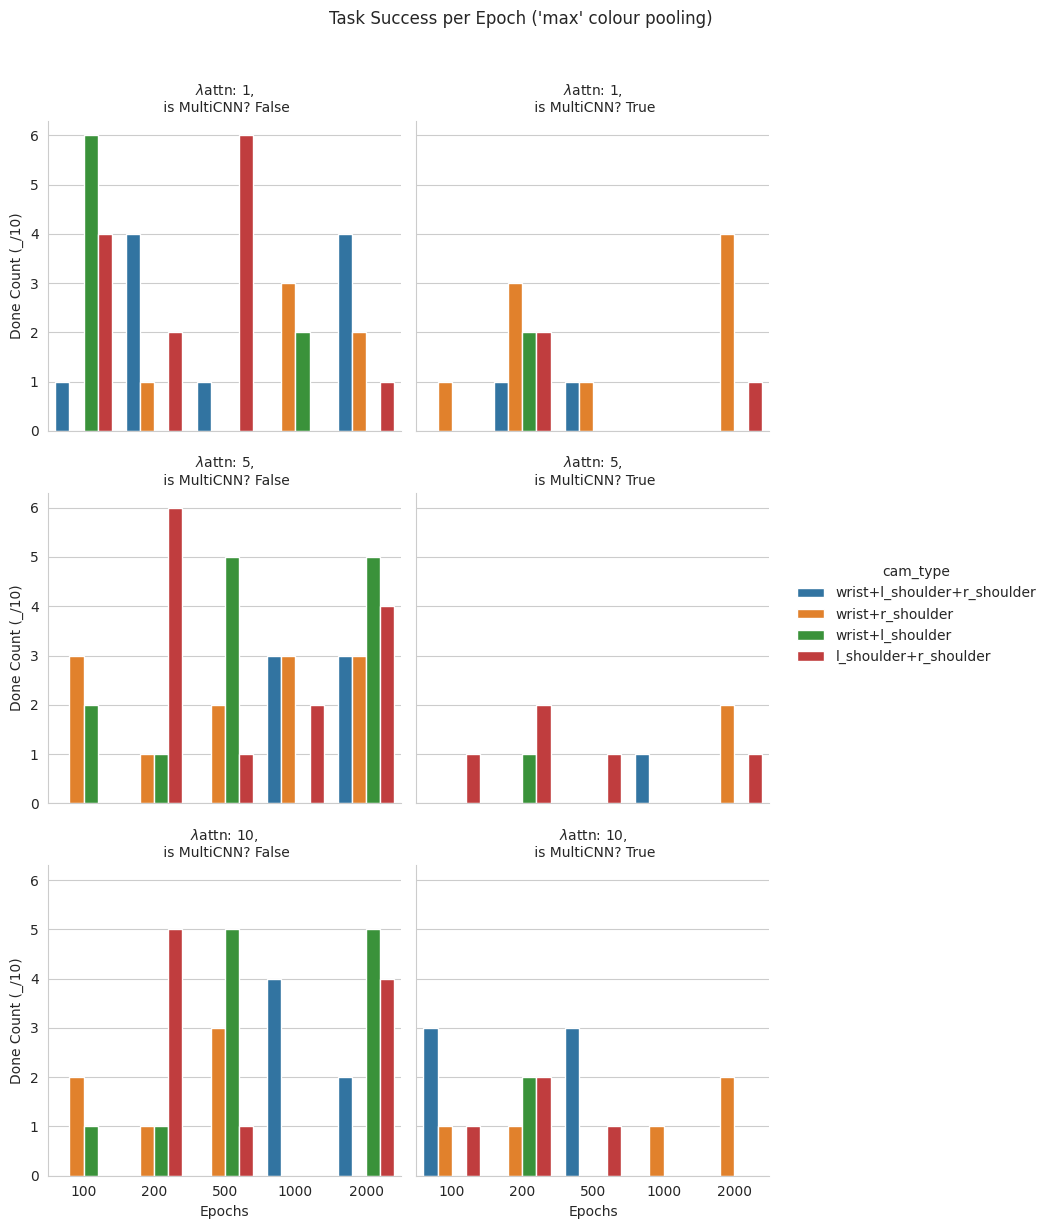

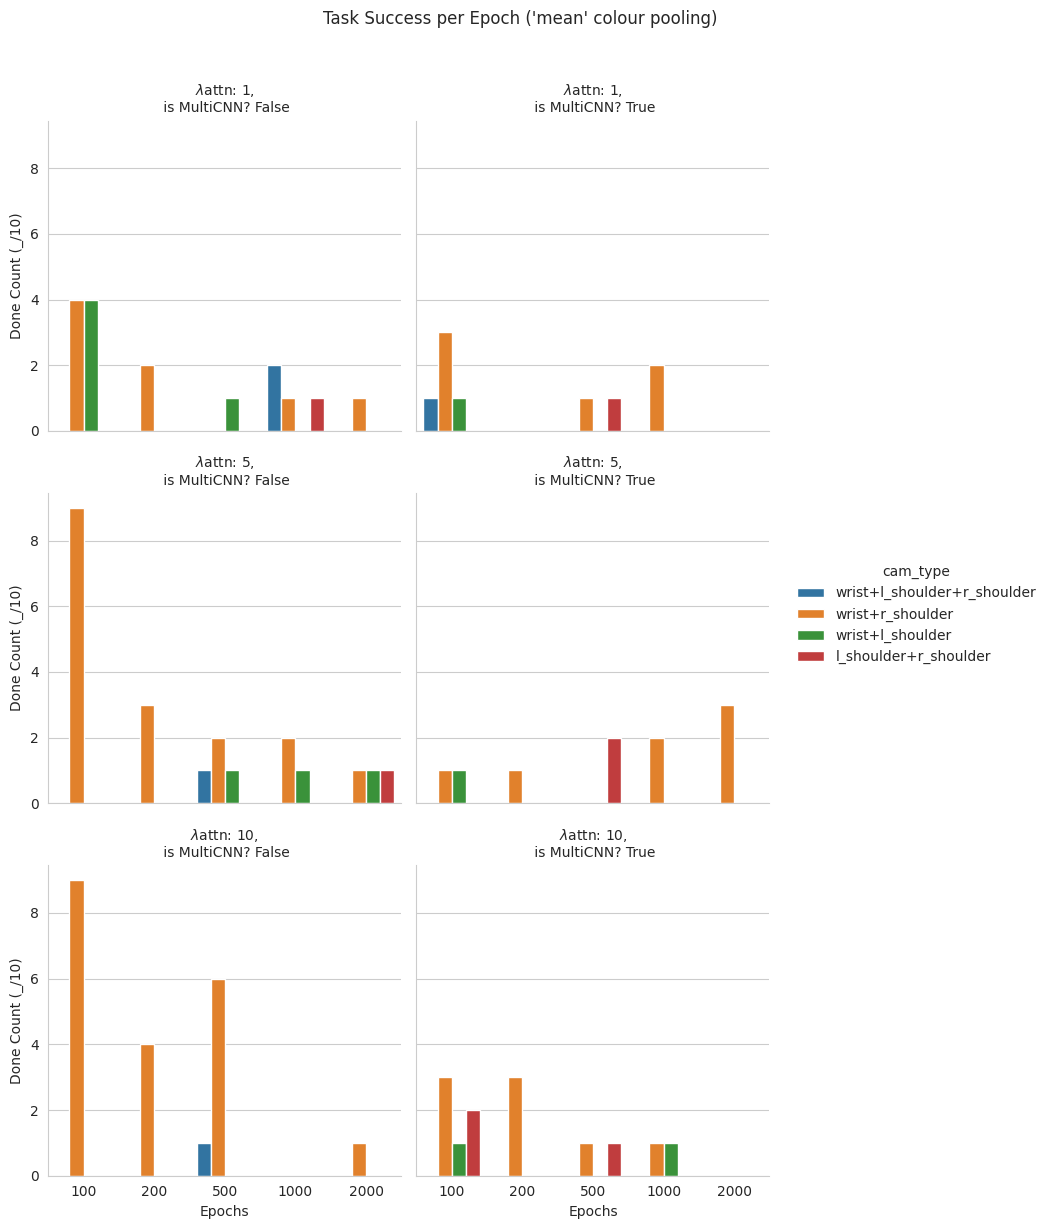

In [ ]:
# Plot
g = sns.catplot(
    data=df_max,
    x='epochs',
    y='belows_none_count',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Done Count (_/10)")
g.figure.suptitle("Task Success per Epoch ('max' colour pooling)", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-max-below-none-count", g = g)
plt.show()

# Plot mean
g = sns.catplot(
    data=df_mean,
    x='epochs',
    y='belows_none_count',
    hue='cam_type',
    col='is_multi_cnn',
    row='lambda_attn',
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
)
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("$\lambda$attn: {row_name},\n is MultiCNN? {col_name}")
g.set_axis_labels("Epochs", "Done Count (_/10)")
g.figure.suptitle("Task Success per Epoch ('mean' colour pooling)", y=1.02)
savefig(f"cam-comb/reach-obs/Z-ro_random-cam_attn-mean-belows-none-count", g = g)
plt.show()


# Depth Interfacing

## Vision Static
the plots from the vs is not the best currently, will first tune then actually run the tests again


### Tuning
Getting some good networks which I can then later use in Depth Interfacing

#### More linear layers

In [111]:
df_all = pd.read_csv("report-data/vision/vision-static/ALLvs-tuning-normal.csv")
df = pd.read_csv("report-data/vision/vision-static/vs-tuning-normal.csv")

no_depth_df = df[~df["cam_type"].str.contains("depth")]
no_depth_df_all = df_all[~df_all["cam_type"].str.contains("depth")]

Text(0.5, 0.98, 'Success Rate per Demo Type and Agent (per seeded Run)')

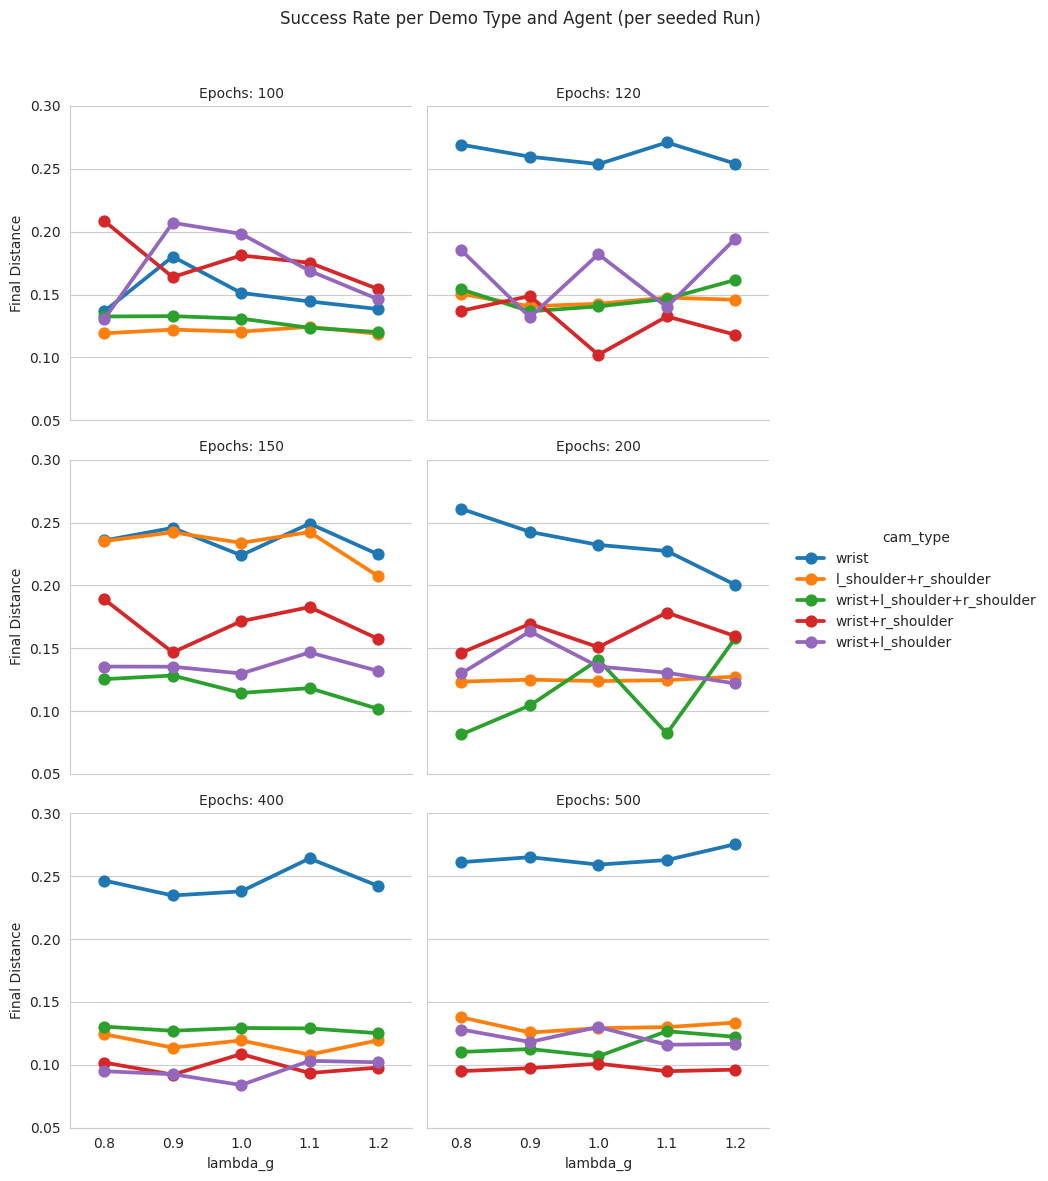

In [112]:
# Plot
g = sns.catplot(
    data=no_depth_df_all,
    x='grasp_loss_lambda',
    y='final_distance',
    hue='cam_type',
    col='epochs',
    kind='point',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    errorbar=None,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("lambda_g", "Final Distance")
g.set(ylim=(0.05, 0.3))
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")


In [ ]:
# Plot
g = sns.catplot(
    data=no_depth_df,
    x='grasp_loss_lambda',
    y='done_count',
    hue='cam_type',
    col='epochs',
    kind='bar',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("lambda_g", "Final Distance")
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.figure.suptitle("Success Rate per Demo Type and Agent (per seeded Run)")

In [ ]:
sns.barplot(data=no_depth_df, x="epochs", y="done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

In [ ]:
sns.barplot(data=no_depth_df, x="grasp_loss_lambda", y="done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Lambda_g")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="upper left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

wrist does not learn well, likely due to there only being one demonstration, this means that there are very 

#### Tuning with the old policy, less linear layers for grasp in `grasp_head`

interesting result here for l shoulder + rshoulder 400 epochs, when it cant see it randomly grasps, which makes sense maybe put this in the report


Using the slightly less deep policy seems to perform the best, feat -> 128 -> 64 -> 1 rather than feat -> 128 -> 64 -> 32 -> 1

Reasons for this i shall understand soon enough

In [6]:
df_all = pd.read_csv("report-data/vision/vision-static/ALLvs-tuning-normal--old-policy.csv")
df = pd.read_csv("report-data/vision/vision-static/vs-tuning-normal--old-policy.csv")

no_depth_df = df[~df["cam_type"].str.contains("depth")]
no_depth_df_all = df_all[~df_all["cam_type"].str.contains("depth")]

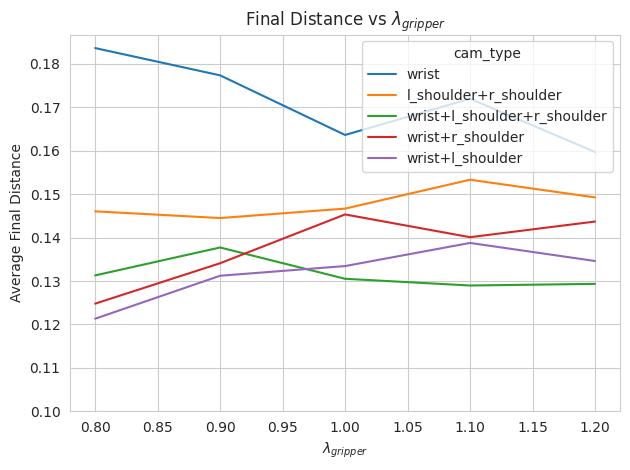

In [7]:
sns.lineplot(
  data=no_depth_df, 
  x="grasp_loss_lambda", 
  y="avg_final_distance", 
  hue="cam_type",
  errorbar=None
)

plt.xlabel("$\lambda_{gripper}$")
plt.ylabel("Average Final Distance")
plt.ylim(0.1) ## bottom of the range, collision around 0.11
plt.title("Final Distance vs $\lambda_{gripper}$")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/grasp-simple/tuning-normal-old-policy-lambda-g.png", format="png", dpi=DPI)
plt.show()


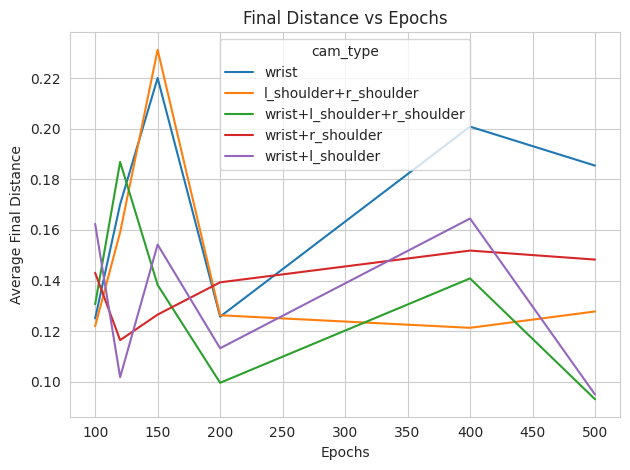

In [8]:
sns.lineplot(
  data=no_depth_df, 
  x="epochs", 
  y="avg_final_distance", 
  hue="cam_type",
  errorbar=None
)

plt.xlabel("Epochs")
plt.ylabel("Average Final Distance")
plt.title("Final Distance vs Epochs")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/grasp-simple/tuning-normal-old-policy-dist.png", format="png", dpi=DPI)
plt.show()

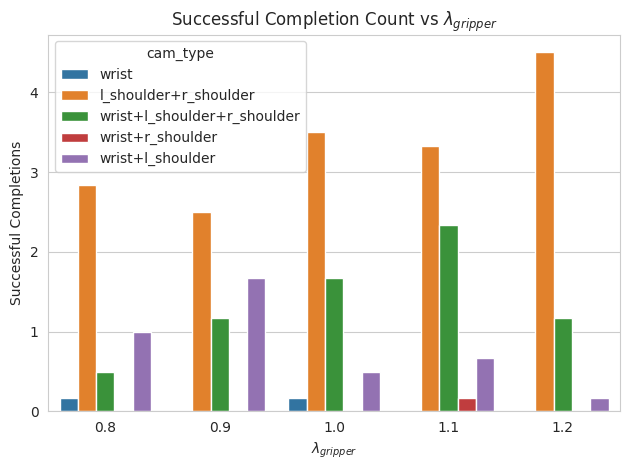

In [9]:
sns.barplot(
  data=no_depth_df, 
  x="grasp_loss_lambda", 
  y="done_count", 
  hue="cam_type",
  errorbar=None
)

plt.xlabel("$\lambda_{gripper}$")
plt.ylabel("Successful Completions")
plt.title("Successful Completion Count vs $\lambda_{gripper}$")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/grasp-simple/tuning-normal-old-policy-success-lambda-g.png", format="png", dpi=DPI)
plt.show()

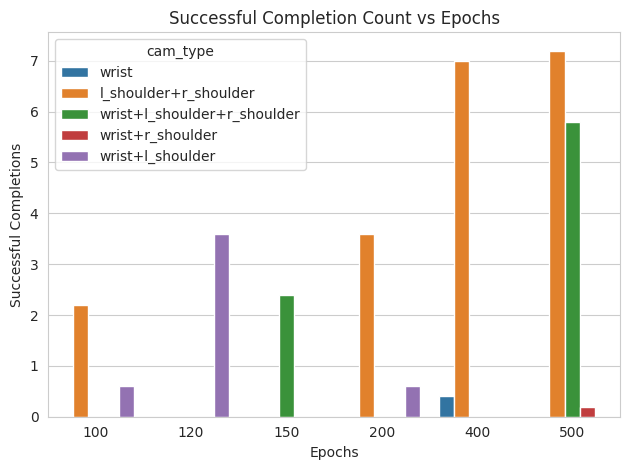

In [10]:
sns.barplot(
  data=no_depth_df, 
  x="epochs", 
  y="done_count", 
  hue="cam_type",
  errorbar=None
)

plt.xlabel("Epochs")
plt.ylabel("Successful Completions")
plt.title("Successful Completion Count vs Epochs")
plt.tight_layout()
plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/grasp-simple/tuning-normal-old-policy-success.png", format="png", dpi=DPI)
plt.show()

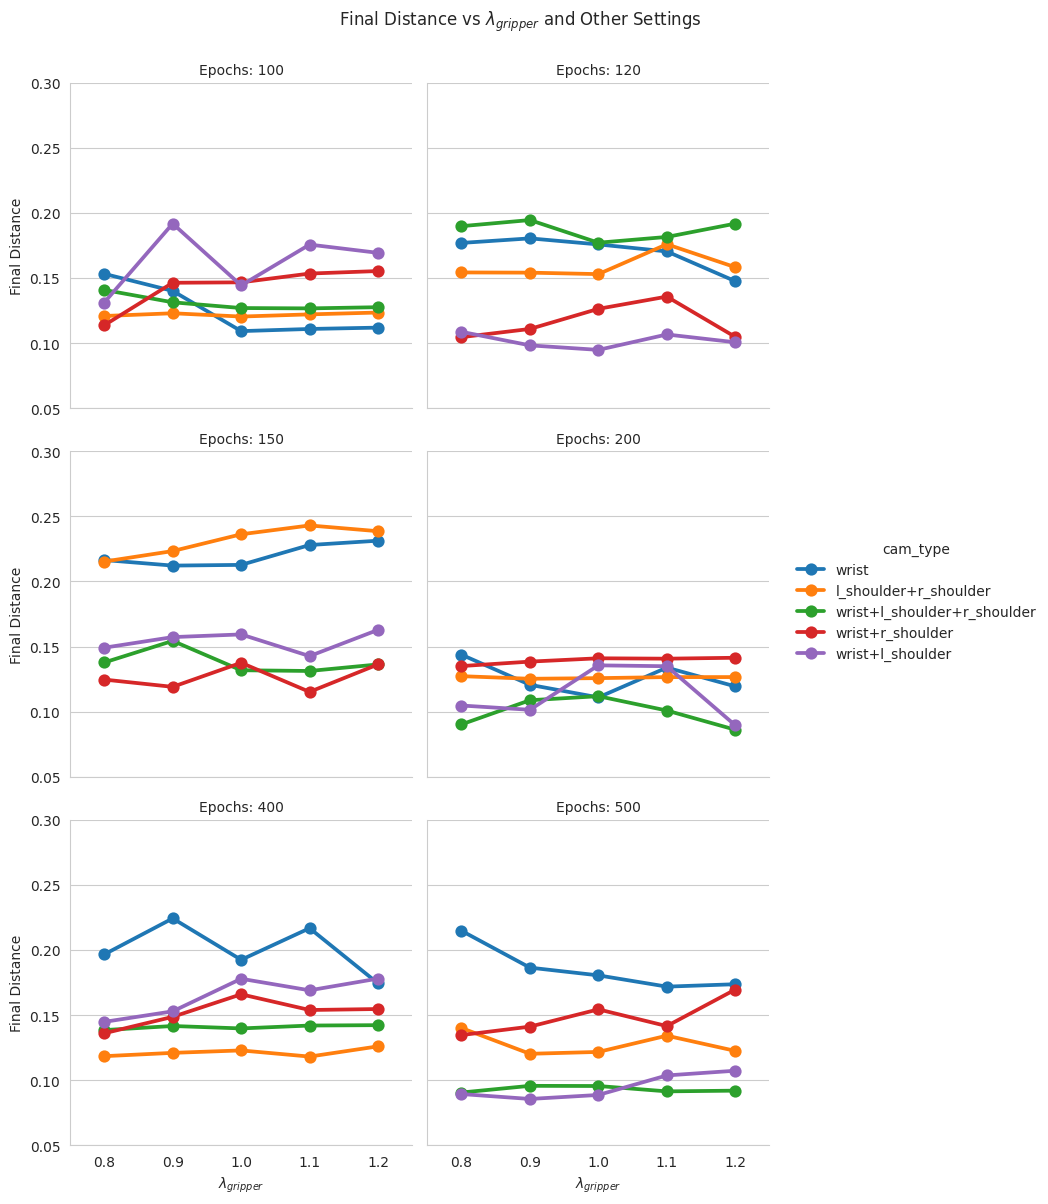

In [11]:
# Plot
# NOTE: APPENDIX ADDITION
g = sns.catplot(
    data=no_depth_df_all,
    x='grasp_loss_lambda',
    y='final_distance',
    hue='cam_type',
    col='epochs',
    kind='point',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    errorbar=None,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("$\lambda_{gripper}$", "Final Distance")
g.set(ylim=(0.05, 0.3))
g.figure.suptitle("Final Distance vs $\lambda_{gripper}$ and Other Settings", y=1)
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy.png", g=g)
plt.show()


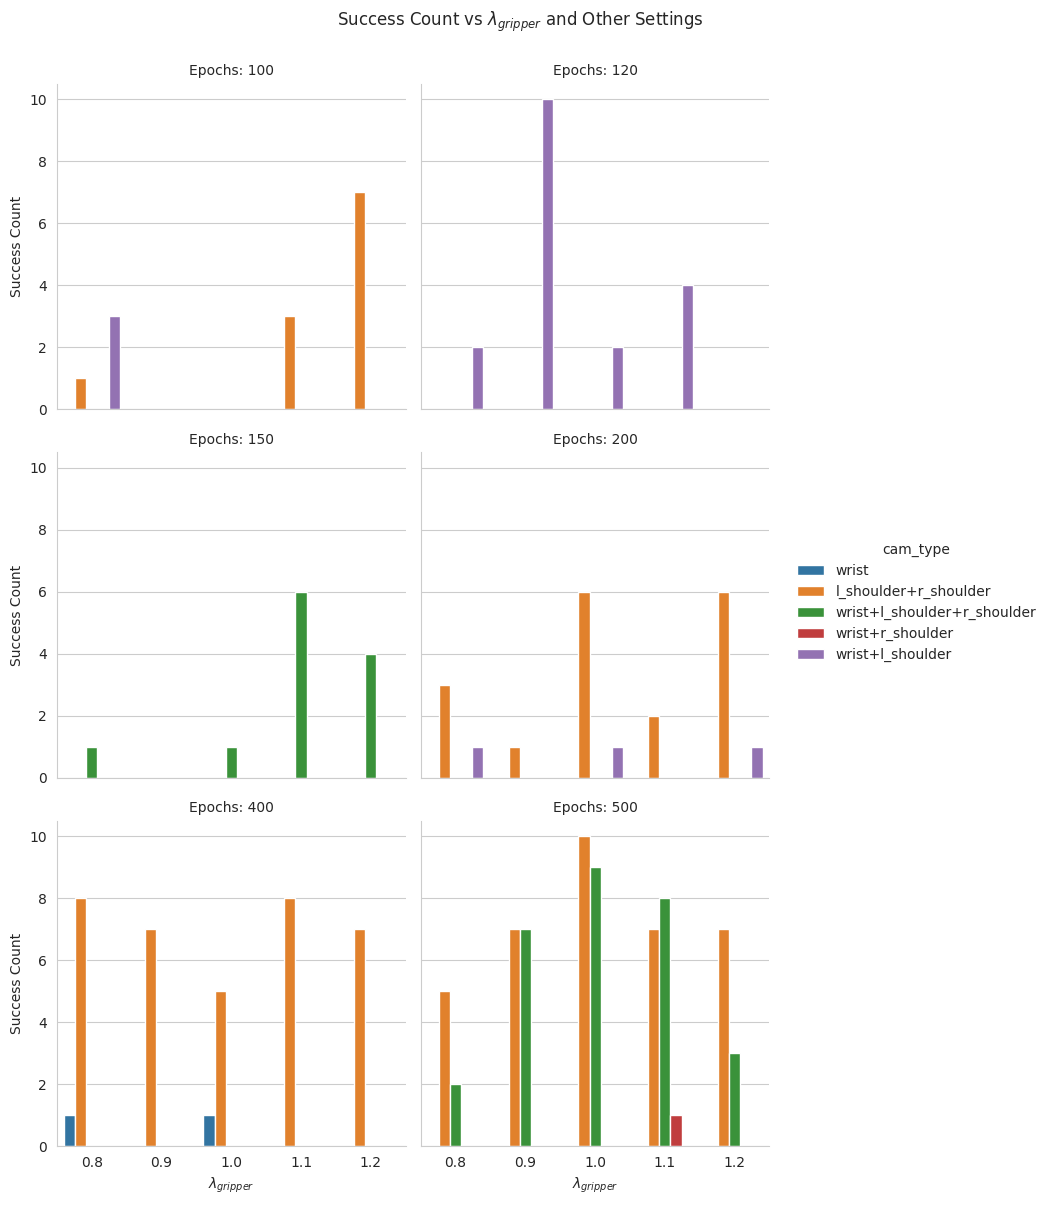

In [12]:
# Plot
g = sns.catplot(
    data=no_depth_df,
    x='grasp_loss_lambda',
    y='done_count',
    hue='cam_type',
    col='epochs',
    kind='bar',
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1
)

g.set_titles("Epochs: {col_name}")
g.set_axis_labels("$\lambda_{gripper}$", "Success Count")
g.figure.suptitle("Success Count vs $\lambda_{gripper}$ and Other Settings", y=1.0)
g.tight_layout()
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy-success.png", g=g)
plt.show()

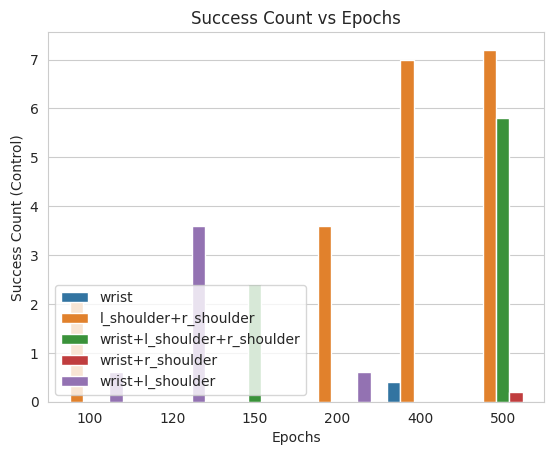

In [13]:
sns.barplot(data=no_depth_df, x="epochs", y="done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="lower left")

# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

The old policy with less linear layers seems to learn well, however we might need to count how many erroneous grasps it does as well, to quantify if this is correct or it is just randomly grasping and eventually getting it right


##### Counting the grasp attempts versus true grasps

In [14]:
ss  = df_all["control_gripper_image_paths"][2096]
splits = ss.split(',')
def grip_counter(s: str) -> int:
  splits = s.split(",")
  if len(splits) == 1 and splits[0] == "[]":
    return len(splits) - 1
  else: 
    return len(splits)
## counting the grip attemps in order to investigate how lucky mmy robot gets
df_all["grasp_attempts"] = df_all["control_gripper_image_paths"].apply(grip_counter)


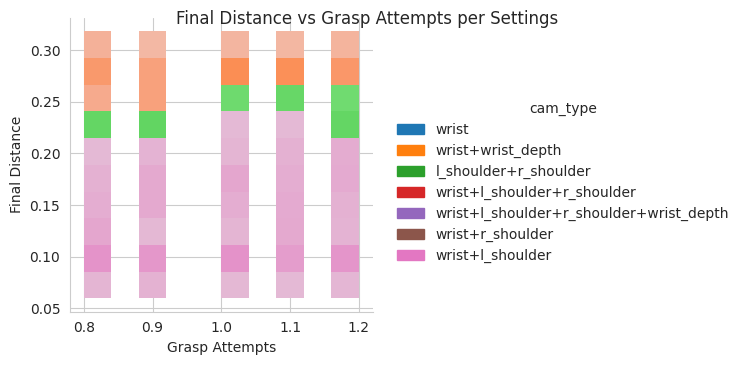

In [15]:
g = sns.displot(
    data=df_all,
    x='grasp_loss_lambda',
    y='final_distance',
    hue='cam_type',
    # col='epochs',
    kind='hist',
    col="task_name",
    # col="control_done",
    col_wrap=1,  # Wrap columns across multiple rows (2 x 5 columns)
    height=4,
    aspect=1,
    bins=10,
)

g.set_titles("")
g.set_axis_labels("Grasp Attempts", "Final Distance")
g.figure.suptitle("Final Distance vs Grasp Attempts per Settings", y=0.9)
g.tight_layout()
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy-lambda-dist-hist-hue-cams.png", g=g)
plt.show()

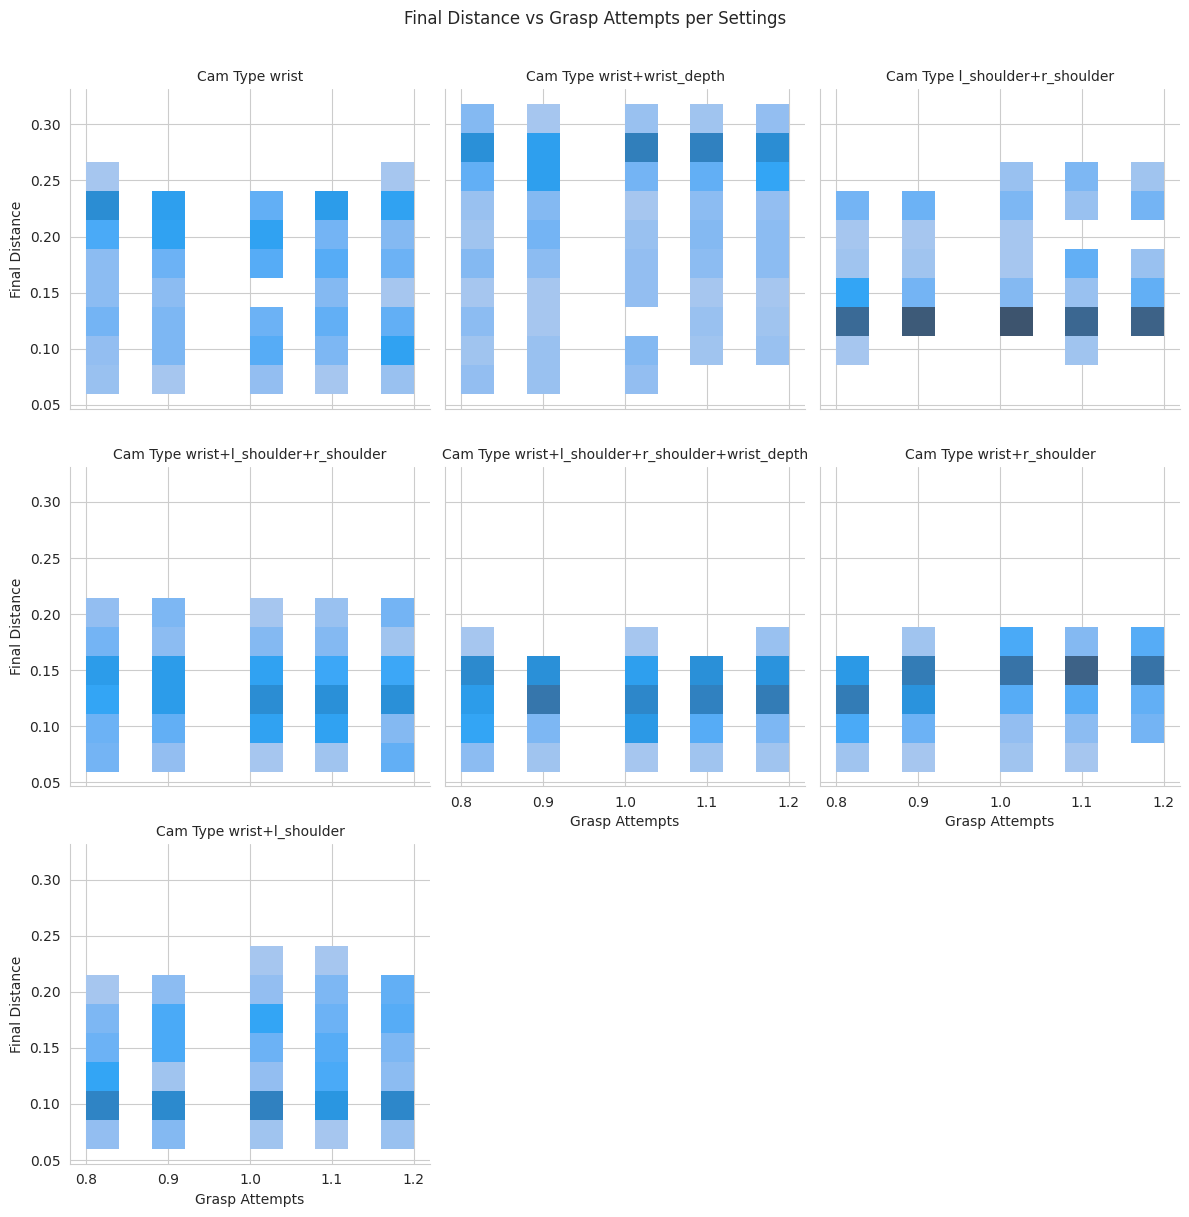

In [18]:
g = sns.displot(
    data=df_all,
    x='grasp_loss_lambda',
    y='final_distance',
    # hue='cam_type',
    col='cam_type',
    kind='hist',
    # col="task_name",
    # col="control_done",
    col_wrap=3,  # Wrap columns across multiple rows (2 x 5 columns)
    height=4,
    aspect=1,
    bins=10,
)

g.set_titles("Cam Type {col_name}")
g.set_axis_labels("Grasp Attempts", "Final Distance")
g.figure.suptitle("Final Distance vs Grasp Attempts per Settings", y=1.01)
g.tight_layout()
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy-lambda-dist-hist.png", g=g)

plt.show()

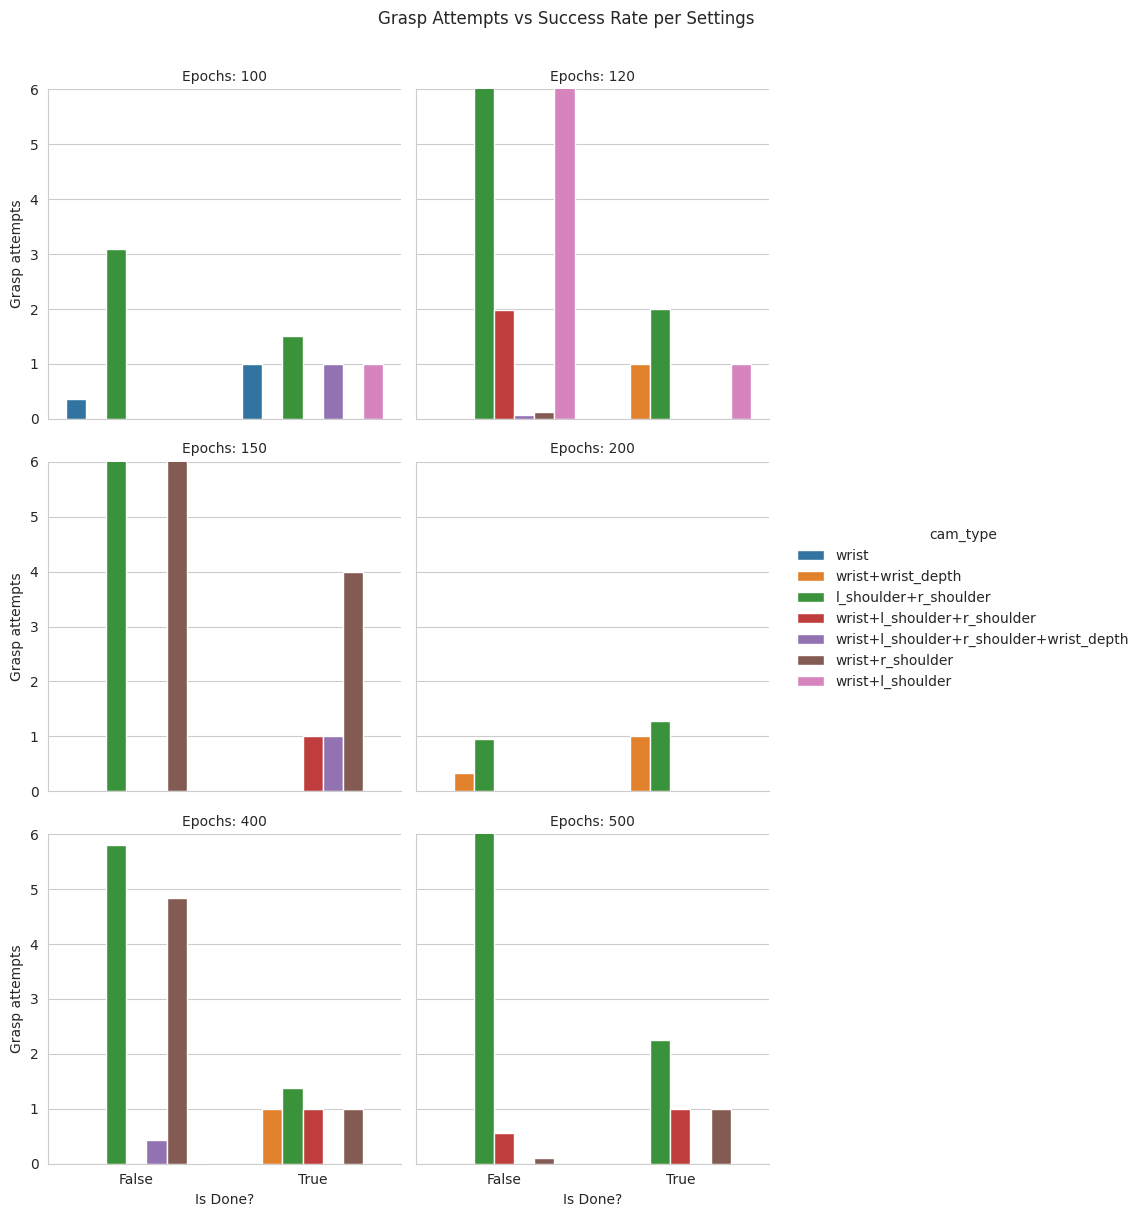

In [ ]:
# Plot
g = sns.catplot(
    data=df_all,
    x='control_done',
    y='grasp_attempts',
    hue='cam_type',
    col='epochs',
    kind='bar',
    # col="control_done",
    col_wrap=2,  # Wrap columns across multiple rows (2 rows x 5 columns)
    height=4,
    aspect=1,
    errorbar=None
)

# g.set_titles("Epochs: {row_name},\n Is Successful: {col_name}")
# g.set_axis_labels("Lambda_g", "Grasp attempts")
# g.tight_layout()
# # g.set(ylim=(-1, 5))
# g.figure.suptitle("Grasp Attempts vs Success Rate per Settings", y=1.01)
# plt.show()
g.set_titles("Epochs: {col_name}")
g.set_axis_labels("Is Done?", "Grasp attempts")
g.set(ylim=(0, 6)) ## arbitrary amouns of retries
g.figure.suptitle("Grasp Attempts vs Success Rate per Settings", y=1.01)
g.tight_layout()
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy-retry-success.png", g=g)
plt.show()


Here we can see that when the episode is successful the policy gets it within 1 to 2 tries, however when it is unsuccessful it will attempt many grasps, inspecting one of the outputs for some policies with many  grasps for example w+l+r [this one](outputs/run-grasp-with-agent/_June03_16-06/wrist+l_shoulder+r_shoulder-closed_at_0.0777-g_pred_(-2.6404)-wrist+l_shoulder+r_shoulder.png) fails because the agent has moved too close too soon, and the policy does not know how to correct its movement, therefore it sits there mashing the wrist camera into the target and keep attempting to grab it

plot a grasp attempts versus the min and final distance graphs:

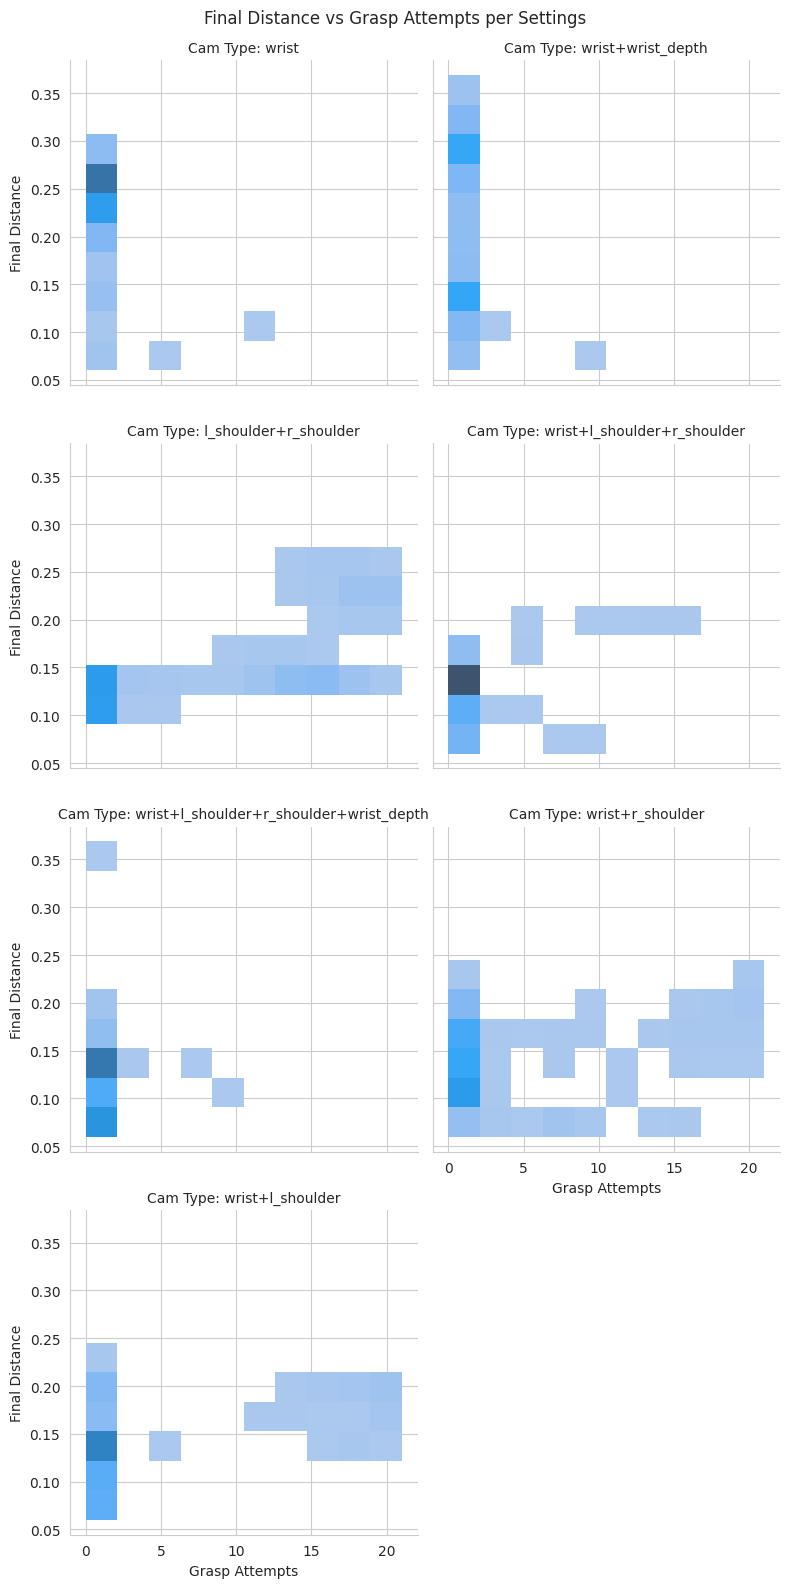

In [ ]:
# Plot

g = sns.displot(
    data=df_all,
    x='grasp_attempts',
    y='final_distance',
    # hue='cam_type',
    # col='epochs',
    kind='hist',
    col="cam_type",
    # col="control_done",
    col_wrap=2,  # Wrap columns across multiple rows (2 x 5 columns)
    height=4,
    aspect=1,
    bins=10,
)

# g.set_titles("Epochs: {row_name},\n Is Successful: {col_name}")
# g.set_axis_labels("Lambda_g", "Grasp attempts")
# g.tight_layout()
# # g.set(ylim=(-1, 5))
# g.figure.suptitle("Grasp Attempts vs Success Rate per Settings", y=1.01)
# plt.show()
g.set_titles("Cam Type: {col_name}")
g.set_axis_labels("Grasp Attempts", "Final Distance")
g.figure.suptitle("Final Distance vs Grasp Attempts per Settings", y=0.99)
g.tight_layout()
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy-retry-dist-hist.png", g=g)
plt.show()

/tmp/ipykernel_276510/2512751747.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  g = sns.displot(
/tmp/ipykernel_276510/2512751747.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  g = sns.displot(
/tmp/ipykernel_276510/2512751747.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  g = sns.displot(
/tmp/ipykernel_276510/2512751747.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  g = sns.displot(
/tmp/ipykernel_276510/2512751747.py:1: UserWarning: KDE cannot be estimated (0 variance or perfect covariance). Pass `warn_singular=False` to disable this warning.
  g = sns.displot(
/tmp/ipykernel_276510/2512751747.py:1: UserWarning: KDE cannot be estimated (0 varian

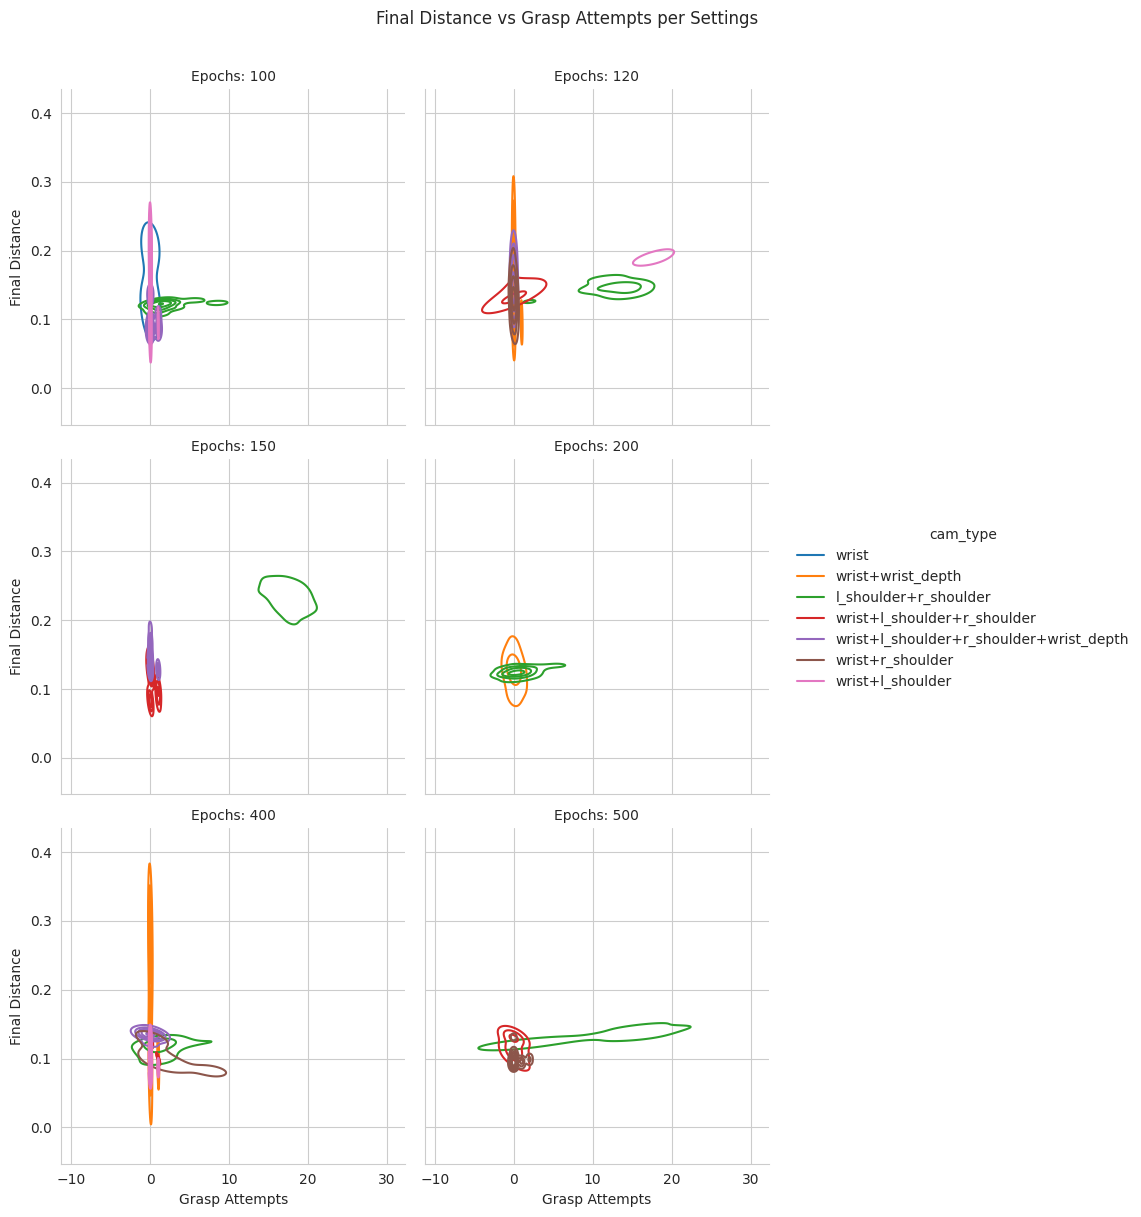

In [ ]:

g = sns.displot(
    data=df_all,
    x='grasp_attempts',
    y='final_distance',
    hue='cam_type',
    col='epochs',
    kind='kde',
    col_wrap=2,  # Wrap columns across multiple rows (2 x 5 columns)
    height=4,
    aspect=1,
    bins=10,
)
g.set_titles("Epochs: {col_name}")
g.set_axis_labels("Grasp Attempts", "Final Distance")
g.figure.suptitle("Final Distance vs Grasp Attempts per Settings", y=1.01)
g.tight_layout()
savefig("cam-comb/grasp-simple/Z-tuning-normal-old-policy-retry-dist-kde.png", g=g)
plt.show()

maybe slap these in the appendix, there is just so much, but not too much to say about them the graph to yap ratio is off so off to the appendix


## Tuning - k-mask checks
Intiial observations from watching the run is that too large of a `k` ~9 makaes the system early grip and keeps early gripping, without moving more, this could be because at that point the movement loss is really low, and the grasp loss over powers the system during training near the end of the sequence, leading the system to attempt to grab too early

In [6]:
df_all = pd.read_csv("report-data/vision/vision-static/ALLvs-tuning-normal--last-k-test2.csv")
df = pd.read_csv("report-data/vision/vision-static/vs-tuning-normal--last-k-test2.csv")
df_all["last_k_mask"] = df_all["last_k_mask"].fillna("all")
df["last_k_mask"] = df["last_k_mask"].fillna("all")

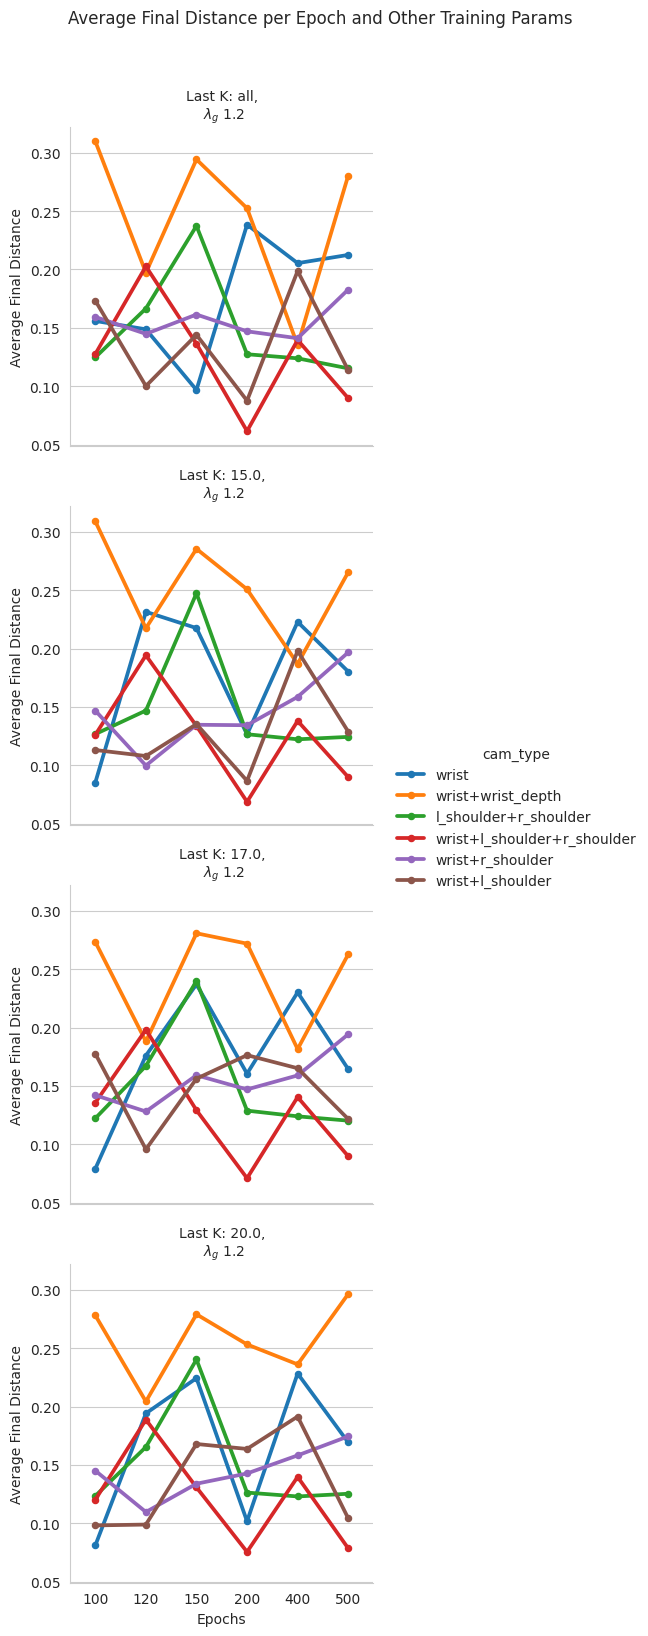

In [7]:
# Plot
g = sns.catplot(
    data=df,
    x='epochs',
    y='avg_final_distance',
    hue='cam_type',
    col='grasp_loss_lambda',
    row='last_k_mask',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

## None in last k means used the old version, loss applied to all steps
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("Last K: {row_name},\n $\lambda_g$ {col_name}")
g.set_axis_labels("Epochs", "Average Final Distance")
g.figure.suptitle("Average Final Distance per Epoch and Other Training Params", y=1.02)#
savefig(f"cam-comb/grasp-simple/Z-last-k-dist.png", g = g)
plt.show()


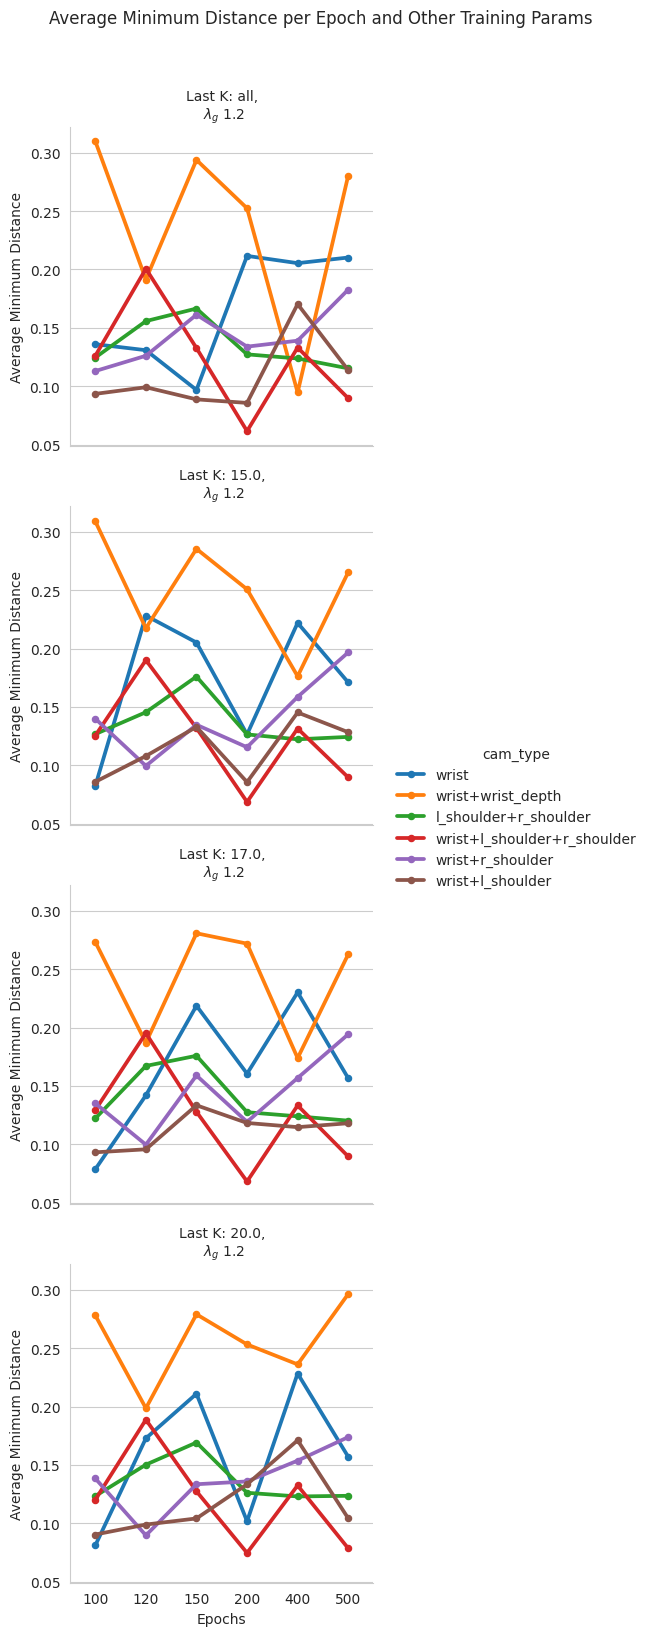

In [8]:
g = sns.catplot(
    data=df,
    x='epochs',
    y='avg_min_distance',
    hue='cam_type',
    col='grasp_loss_lambda',
    row='last_k_mask',
    kind="point",
    errorbar=None,
    markers=["."] * 10,
    palette="tab10",
    height=4,
    aspect=1,
)

## None in last k means used the old version, loss applied to all steps
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("Last K: {row_name},\n $\lambda_g$ {col_name}")
g.set_axis_labels("Epochs", "Average Minimum Distance")
g.figure.suptitle("Average Minimum Distance per Epoch and Other Training Params", y=1.02)#
savefig(f"cam-comb/grasp-simple/Z-last-k-mindist", g = g)
plt.show()

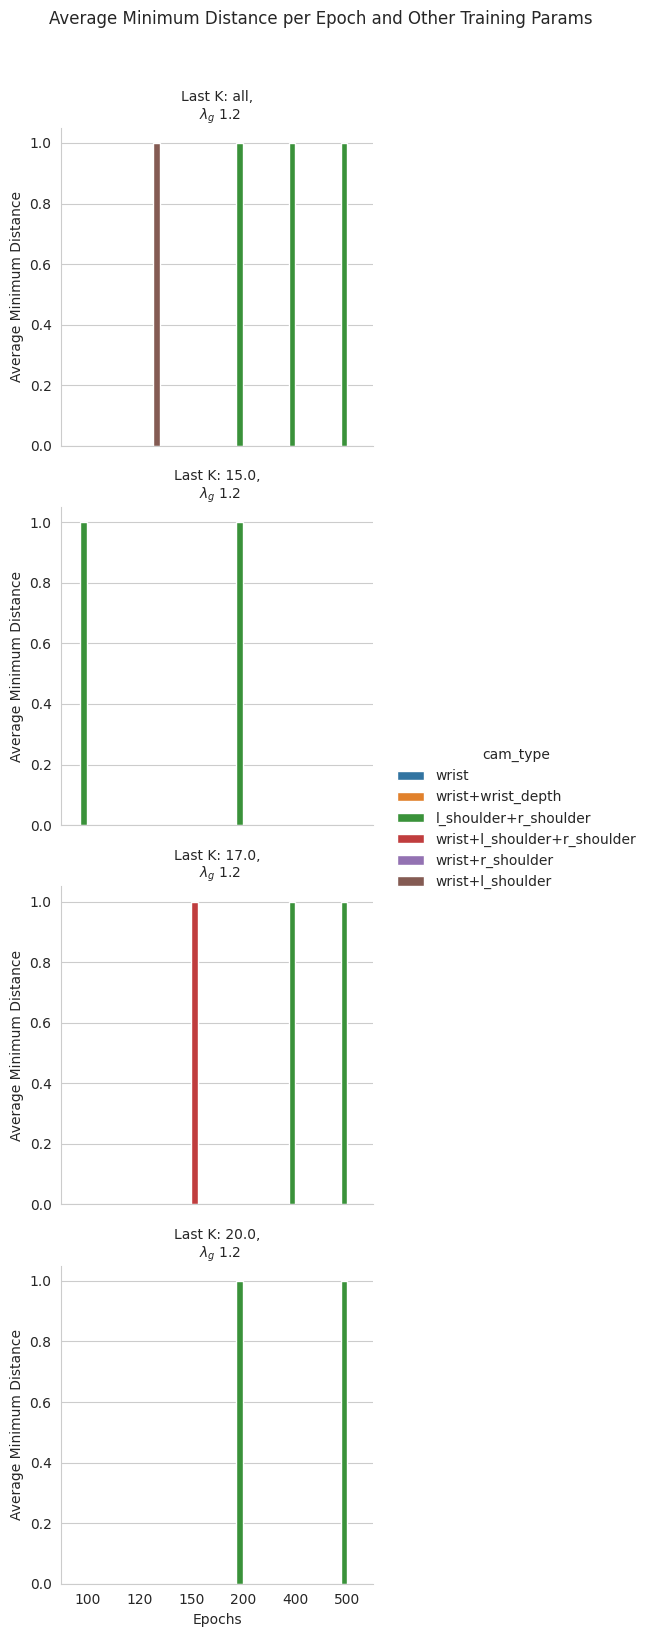

: 

In [ ]:
g = sns.catplot(
    data=df,
    x='epochs',
    y='done_count',
    hue='cam_type',
    col='grasp_loss_lambda',
    row='last_k_mask',
    kind="bar",
    errorbar=None,
    palette="tab10",
    height=4,
    aspect=1,
)

## None in last k means used the old version, loss applied to all steps
g.figure.subplots_adjust(hspace=0.2)
g.set_titles("Last K: {row_name},\n $\lambda_g$ {col_name}")
g.set_axis_labels("Epochs", "Average Minimum Distance")
g.figure.suptitle("Average Minimum Distance per Epoch and Other Training Params", y=1.02)#
savefig(f"cam-comb/grasp-simple/Z-last-k-success", g = g)
plt.show()

### Normal and Small size performance comparison

there is a few versions of this, however dont want to run for many epochs will run reach obs tonight will see what I can do with this tmr night

In [19]:
full_df = pd.read_csv("report-data/vision/vision-static/vs-train_normal-test_small.csv")
df = full_df[~full_df["cam_type"].str.contains("depth")]

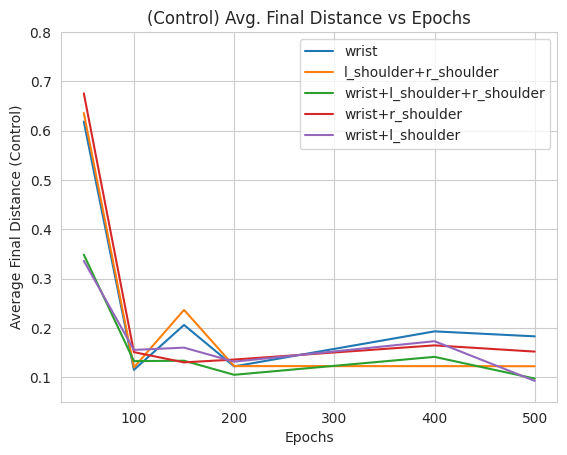

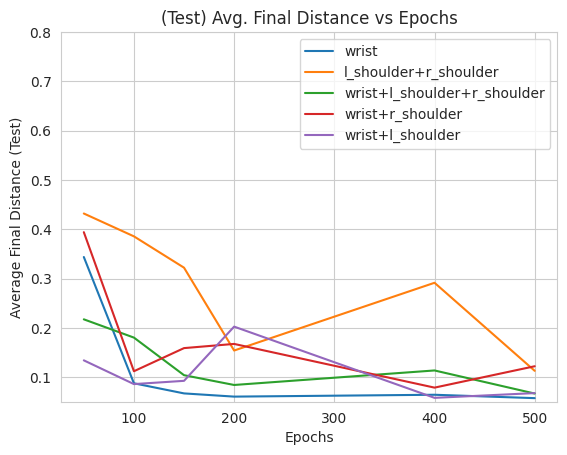

In [20]:
sns.lineplot(data=df, x="epochs", y="control_final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Average Final Distance (Control)")
plt.title("(Control) Avg. Final Distance vs Epochs")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()
# Plot

sns.lineplot(data=df, x="epochs", y="test_final_distance", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Average Final Distance (Test)")
plt.title("(Test) Avg. Final Distance vs Epochs")
plt.ylim(0.05, 0.8)
plt.legend(loc="upper right")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()


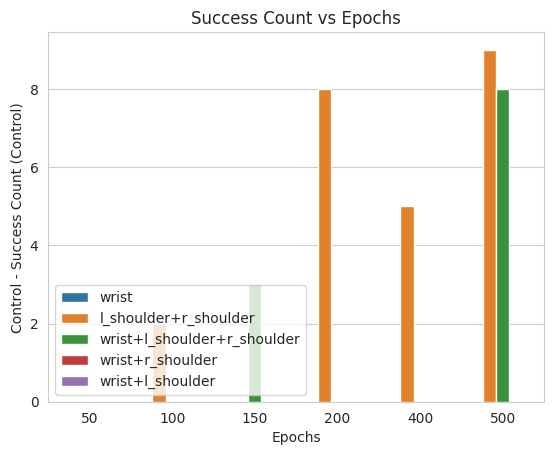

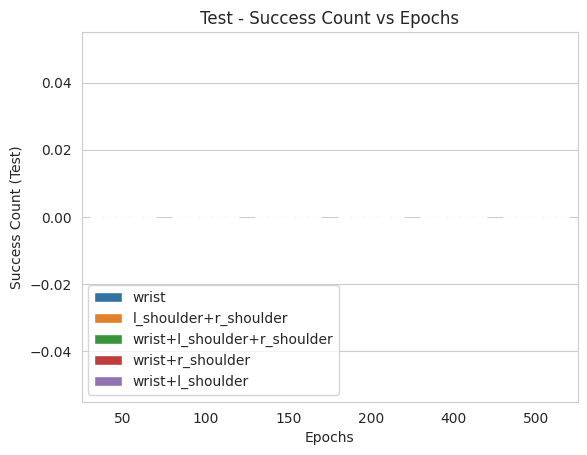

In [24]:
sns.barplot(data=df, x="epochs", y="control_done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Control - Success Count (Control)")
plt.title("Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

sns.barplot(data=df, x="epochs", y="test_done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Test)")
plt.title("Test - Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()

The testing is not successful at all, we can't extract useful enough information here

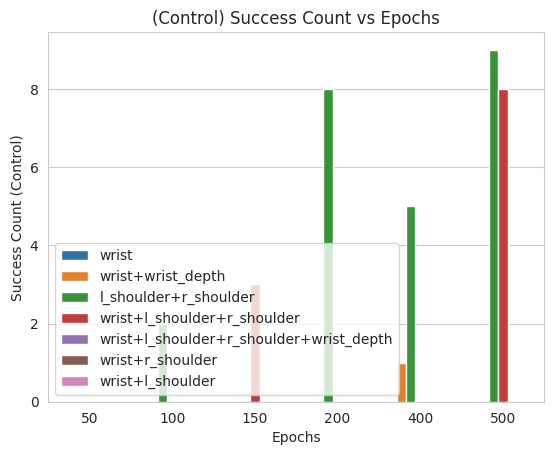

In [25]:
## this includew depth cameras the other one earlier ones do not

sns.barplot(data=full_df, x="epochs", y="control_done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Control)")
plt.title("(Control) Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()


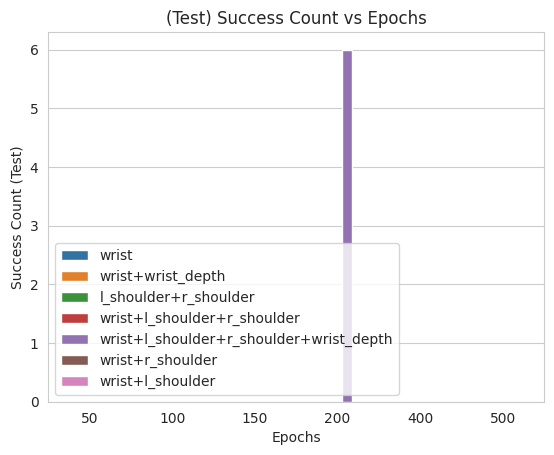

In [23]:
## includes depth
sns.barplot(data=full_df, x="epochs", y="test_done_count", hue="cam_type", errorbar=None, palette="tab10")
plt.xlabel("Epochs")
plt.ylabel("Success Count (Test)")
plt.title("(Test) Success Count vs Epochs")
plt.legend(loc="lower left")
# plt.savefig("/home/kup/Desktop/code/fyp-report/assets/cam-comb/reach-obs/vs_static-", format="png", dpi=DPI)
plt.show()


There is no **test** success at all unless all the cameras are being used, however this policy is not effective in the normal size, so this is slightly weird, it performs well in the second task because it learns the original task wrong?

NOTE: This might be a good mention in the report

# Next Section
